# Hyperparameter Optimization

This notebook builds based on `1_basic_tutorial.ipynb` by calling optimization routines to find optimal parameters for each method.

### Notations:
  * dt: (float) step size (note: the symbol "dt" comes from differentiating timeseries data, however these functions work for a 1-dimensional spatial derivative as well)
  * x: (np.array with length N) the data you want to differentiate
  * x_hat: (np.array with length N) the smoothed estimate of x
  * x_truth: (np.array with length N) the true value of x (which is known when the data is simulated, and used for plotting purposes only)
  * dxdt_hat: (np.array with length N) the estimate of the derivative of x
  * dxdt_truth: (np.array with length N) the true value of dxdt (which is known when the data is simulated, and used for plotting purposes only)

In [1]:
import numpy as np
from matplotlib import pyplot
from time import time
from pynumdiff.optimize import optimize as _optimize
def optimize(*args, **kwargs): # wrap the optimize method to print time taken
	t = time(); out = _optimize(*args, **kwargs); print(f"optimize({args[0].__name__}) took {time() - t:.2f}s"); return out
from pynumdiff.utils import evaluate
from pynumdiff.utils.simulate import sine, triangle, pop_dyn, linear_autonomous, pi_cruise_control, lorenz_x
from pynumdiff.finite_difference import finitediff
from pynumdiff.smooth_finite_difference import kerneldiff, butterdiff
from pynumdiff.polynomial_fit import splinediff, polydiff, savgoldiff
from pynumdiff.basis_fit import spectraldiff, rbfdiff, waveletdiff
from pynumdiff.total_variation_regularization import tvrdiff, smooth_acceleration
from pynumdiff.kalman_smooth import rtsdiff, robustdiff
from pynumdiff.linear_model import lineardiff


## Optimizing with and without ground truth

There are two main scenarios:
1. The true derivative is known, so we can target it directly
2. Actual dxdt is unknown, so we have to target a proxy

In the real world, option (1) is not possible, so for (2) we use a loss function that balances the faithfulness and smoothness of the derivative estimate, balanced by a single weight $\gamma$, which `optimize` derives internally from the `bandlimit` you give it:

$$L(\Phi) = \sigma_\text{MAD} \sqrt{\frac{2}{N}\sum\text{Huber}\bigg(M, \frac{\text{trapz}(\mathbf{\hat{\dot{x}}}(\Phi)) + c - \mathbf{y}}{\sigma_\text{MAD}}\bigg)} + \gamma\,\text{TV}\big(\mathbf{\hat{\dot{x}}}(\Phi)\big)$$

where $\Phi$ are the hyperparameter settings of a differentiation method, $\mathbf{\hat{\dot{x}}}(\Phi)$ is an estimate of the derivative, the left term is a generalization of $\text{RMSE}$ that uses the Huber loss, $\sigma_\text{MAD}$ is a robust scatter measure (median absolute deviation), $M$ is a robustness parameter in units of $\sigma_\text{MAD}$ (often set to 2 or 3 so the vast majority of inliers are measured with RMSE), $\text{trapz}$ performs trapezoidal integration, $c$ corrects for a lost constant of integration (outlier-robustly), $\mathbf{y}$ is noisy data, $\gamma$ is a hyper-parameter, and $TV$ is the total variation:

$$\text{TV}(\mathbf{\hat{\dot{x}}}) = \frac{1}{m}\left\lVert\mathbf{\hat{\dot{x}}}_{0:m-1}-\mathbf{\hat{\dot{x}}}_{1:m}\right\rVert_{1}$$

See the paper for more detail. You never set $\gamma$ directly; you give `optimize` a `bandlimit` and it derives $\gamma$ from that, since the same $\gamma$ means different things at different sampling rates. Choosing the cutoff is a judgment about your own data:

In [2]:
noise_type = 'normal' # noise is generated using np.random, e.g. 'normal', 'uniform', 'poisson'
noise_parameters = [0, 0.1]  # compatible with np.random functions 
dt = 0.01 # step size and series length in terms of independent variable
duration = 4
problem = pi_cruise_control # select one of the options imported from the simulate module
bandlimit = 2.5 # highest frequency at which the data carries real signal, in Hz

# estimate by (a) counting real # peaks per second in the data or (b) look at power spectrum and choose cutoff.

Optimization follows this pattern:

```python
from pynumdiff.optimize import optimize
from pynumdiff.module import method

search_space_updates = {'param1':[values], 'param2':[values], ...}

params, val = optimize(method, x, dt,
                    bandlimit=bandlimit, # the interpretable knob; gamma is derived from it
                    dxdt_truth=dxdt_truth, # defaults to None if no ground truth data
                    search_space_updates=search_space_updates)
					
x_hat, dxdt_hat = method(x, dt, **params)
```

where `param`s are keyword arguments that come from the method definition. If you don't know a search space, default search spaces are defined for all methods in `optimize.py`. Partial search spaces are accepted, simply replacing relevant entries in the default search space. Reasonable upper and lower bounds are defined for numerical search space dimensions (type `int` or `float`). Categorical dimensions can also be searched over by providing values in sets rather than lists.

Only either `bandlimit` or `dxdt_truth` is needed, to target either the proxy loss or the true derivative.

# 0. Simulate some data

pynumdiff comes with 6 different toy problems (choose the one that most resembles your data to see how the methods compare):
* lorenz_x: (nonlinear) x component of a lorenz attractor
* sine: (linear) sum of two sines
* pop_dyn: (nonlinear) bounded exponential growth
* triangle: (nonlinear) sharp-edged triangle wave with increasing frequency
* pi_cruise_control: (linear / nonlinear) linear proportional integral controller with nonlinear control inputs

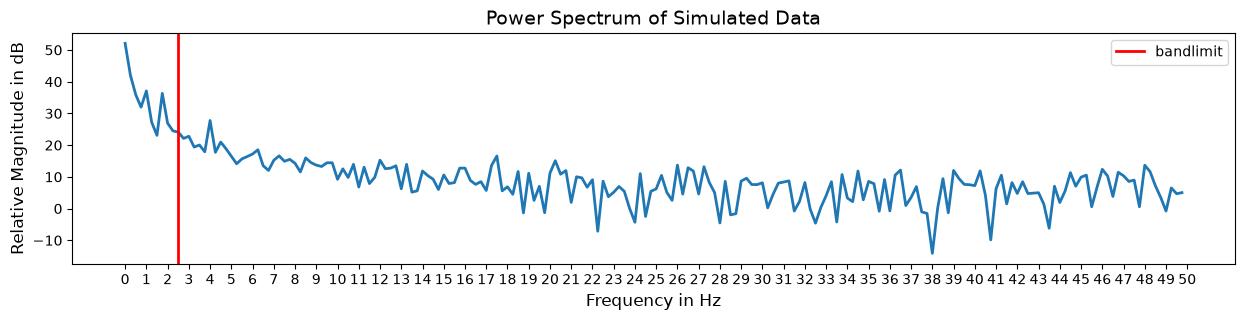

In [3]:
x, x_truth, dxdt_truth = problem(duration, noise_type=noise_type, outliers=False,
                                noise_parameters=noise_parameters, dt=dt)

X = np.fft.fft(x)
energy = 20*np.log10(np.abs(X))
freqs = np.fft.fftfreq(len(X), dt)
energy = energy[freqs >=0]
freqs = freqs[freqs >= 0]

pyplot.figure(figsize=(15,3))
pyplot.plot(freqs, energy, linewidth=2)
pyplot.axvline(x=bandlimit, color='red', linewidth=2, label="bandlimit")
pyplot.xticks(np.arange(51))
pyplot.title("Power Spectrum of Simulated Data", fontsize=14)
pyplot.xlabel("Frequency in Hz", fontsize=12)
pyplot.ylabel("Relative Magnitude in dB", fontsize=12)
pyplot.legend();

## 1. Smooth Finite Difference

### 1.1 Kernel smoothing

optimize(kerneldiff) took 1.33s
Optimal parameters: {'window_size': 19, 'num_iterations': 1, 'kernel': 'friedrichs'}
val = 0.636114599995165 is the minimal 'rmse' by default but can also minimize 'error_correlation'
optimize(kerneldiff) took 1.88s
Optimal parameters: {'window_size': 17, 'num_iterations': 1, 'kernel': 'gaussian'} loss: 0.1061808674236484


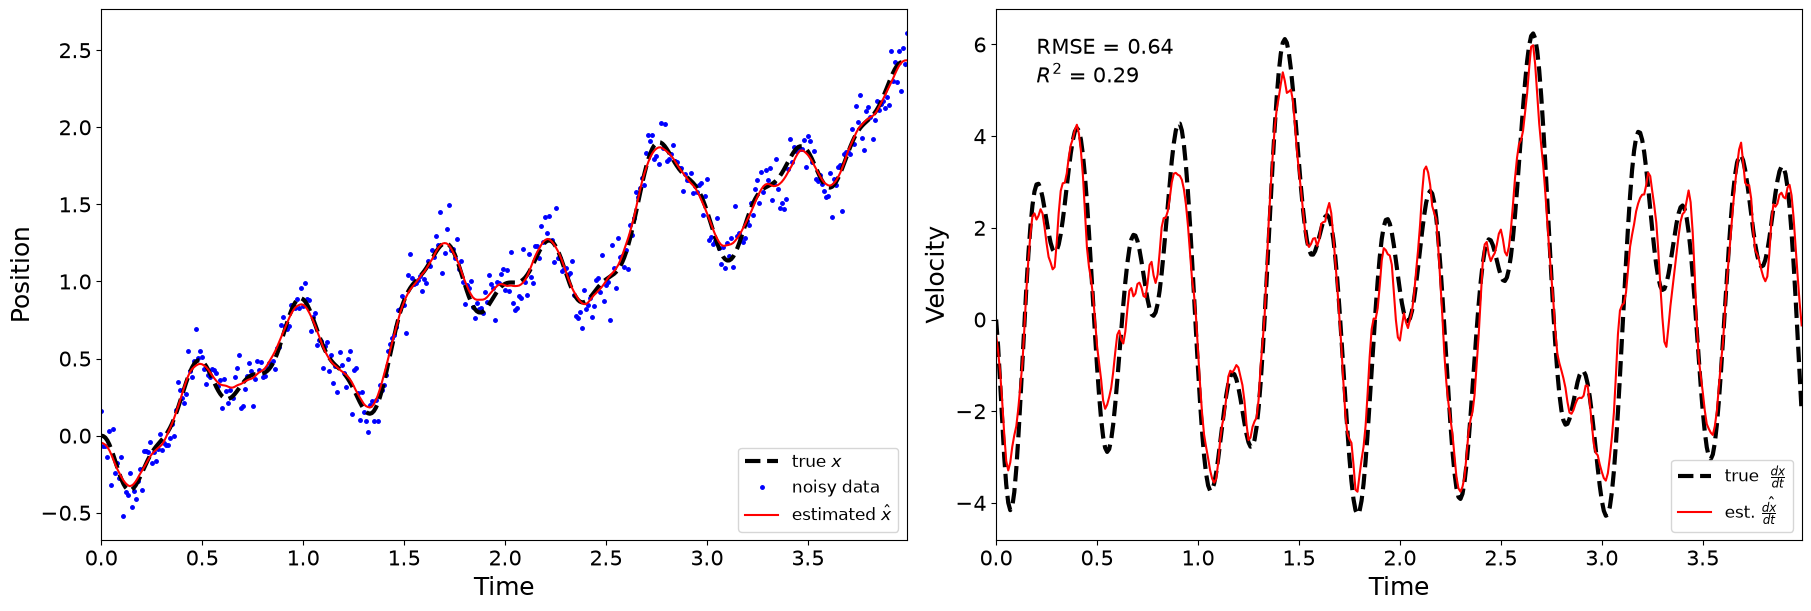

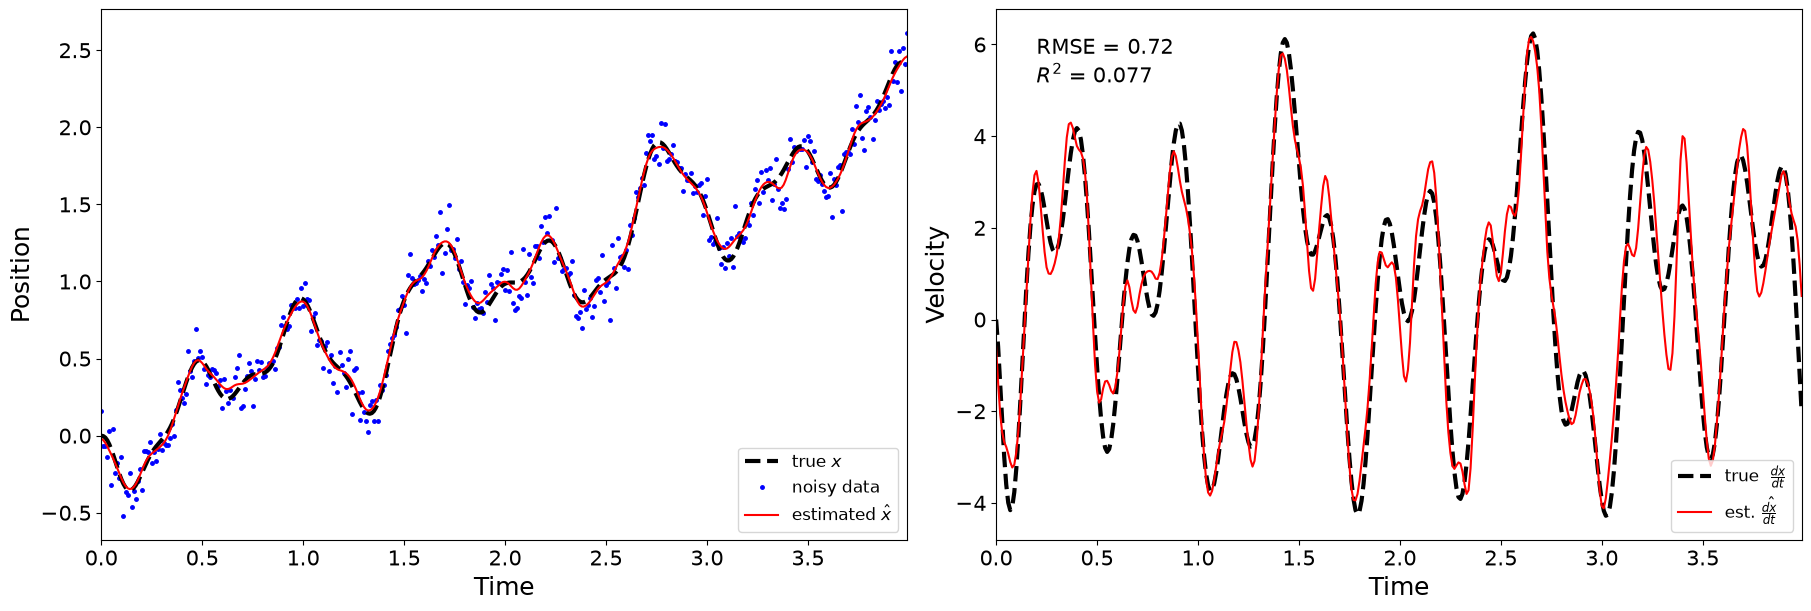

In [4]:
params, val = optimize(kerneldiff, x, dt, dxdt_truth=dxdt_truth, metric='rmse')
print('Optimal parameters:', params)
print(f"val = {val} is the minimal 'rmse' by default but can also minimize 'error_correlation'")
x_hat, dxdt_hat = kerneldiff(x, dt, **params)
evaluate.plot(x, dt, x_hat, dxdt_hat, x_truth, dxdt_truth);

params, val = optimize(kerneldiff, x, dt, bandlimit=bandlimit) # can use huberM here if there are outliers
print('Optimal parameters:', params, 'loss:', val)
x_hat, dxdt_hat = kerneldiff(x, dt, **params)
evaluate.plot(x, dt, x_hat, dxdt_hat, x_truth, dxdt_truth);

### 1.2 Butterworth smoothing

optimize(butterdiff) took 1.72s
Optimal parameters: {'cutoff_freq': np.float64(0.1499999999999997), 'num_iterations': 14, 'filter_order': 5}
optimize(butterdiff) took 4.48s
Optimal parameters: {'cutoff_freq': np.float64(0.11750000000000005), 'num_iterations': 1, 'filter_order': 2} loss: 0.10584600420223544


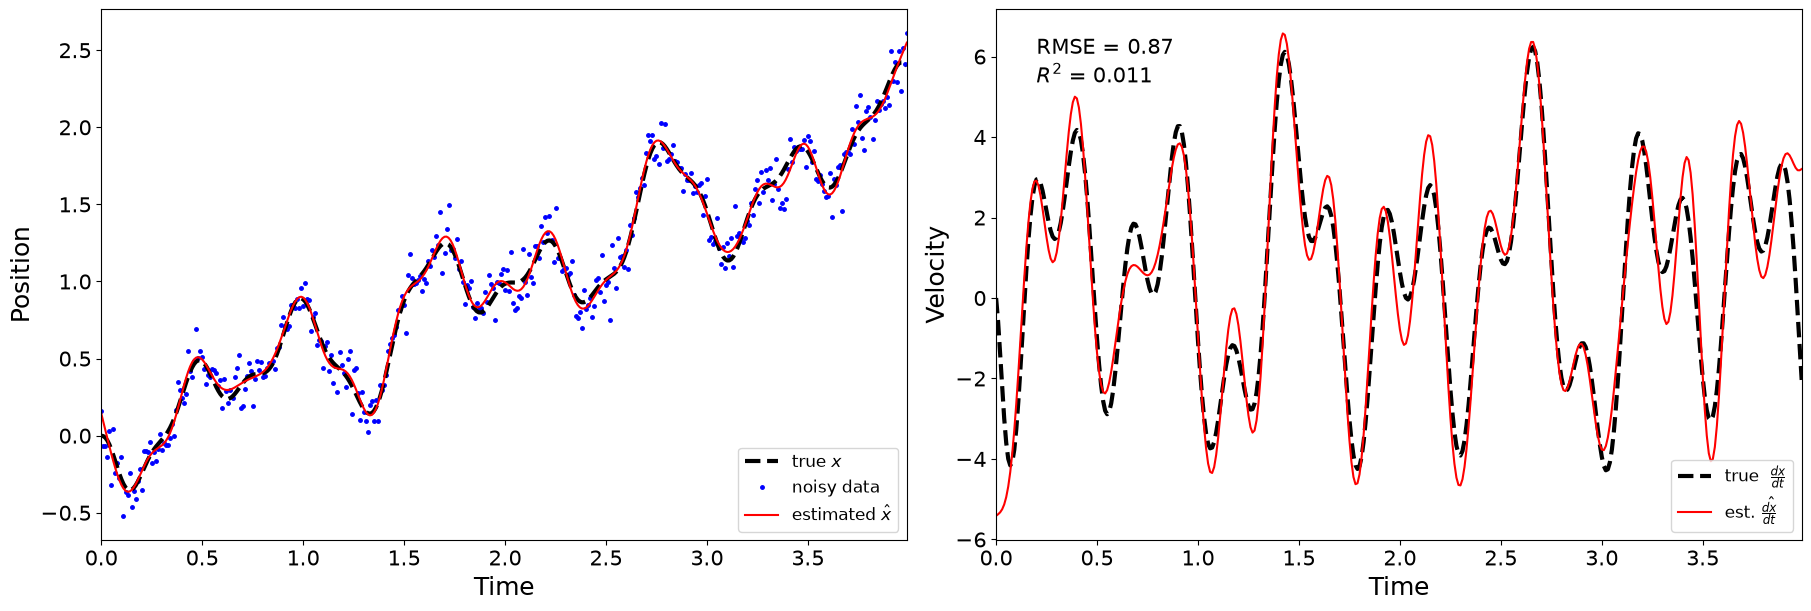

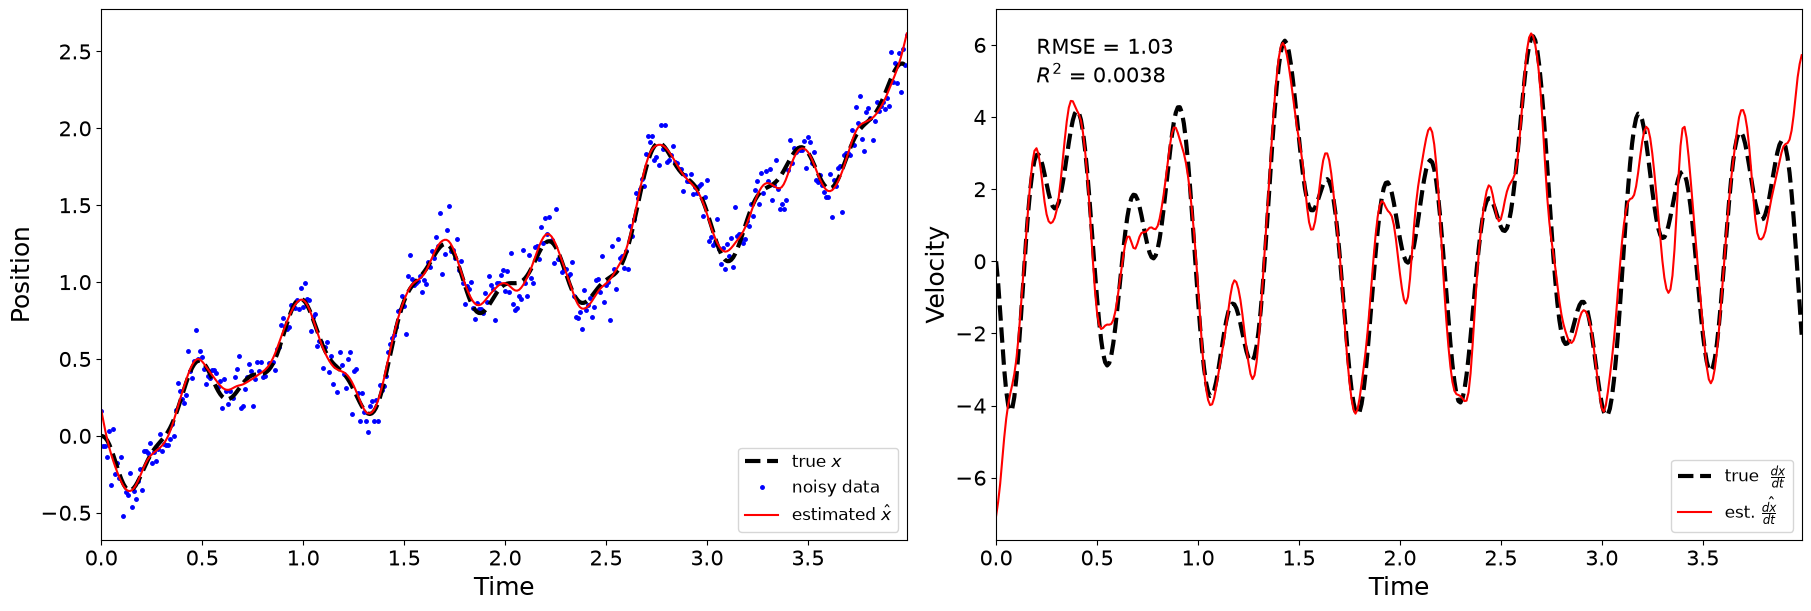

In [5]:
params, val = optimize(butterdiff, x, dt, dxdt_truth=dxdt_truth)
print('Optimal parameters:', params)
x_hat, dxdt_hat = butterdiff(x, dt, **params)
evaluate.plot(x, dt, x_hat, dxdt_hat, x_truth, dxdt_truth);

params, val = optimize(butterdiff, x, dt, bandlimit=bandlimit)
print('Optimal parameters:', params, 'loss:', val)
x_hat, dxdt_hat = butterdiff(x, dt, **params)
evaluate.plot(x, dt, x_hat, dxdt_hat, x_truth, dxdt_truth);

## 2. Iterated Finite Difference

optimize(finitediff) took 1.35s
Optimal parameters: {'num_iterations': 79, 'order': 4}
optimize(finitediff) took 1.38s
Optimal parameters: {'num_iterations': 53, 'order': 4} loss: 0.1054061999985822


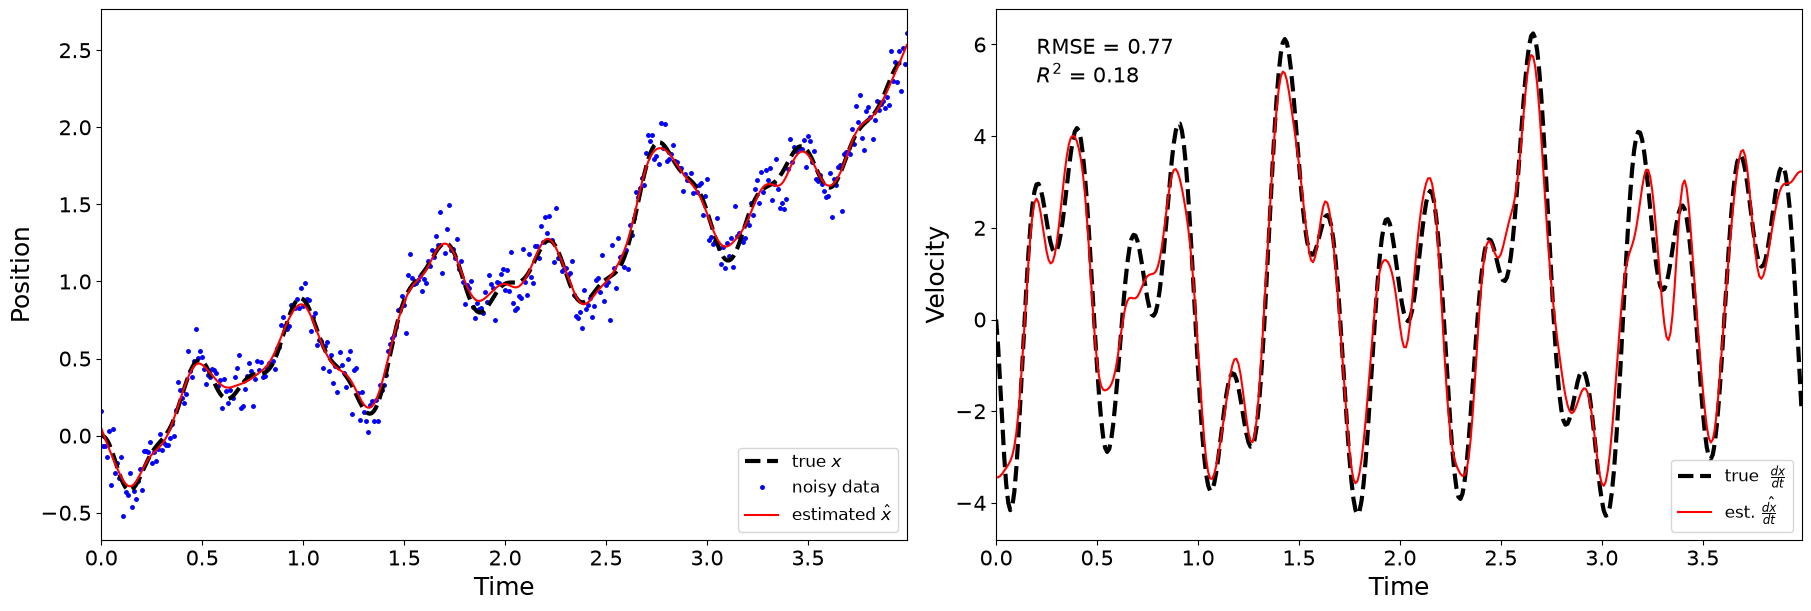

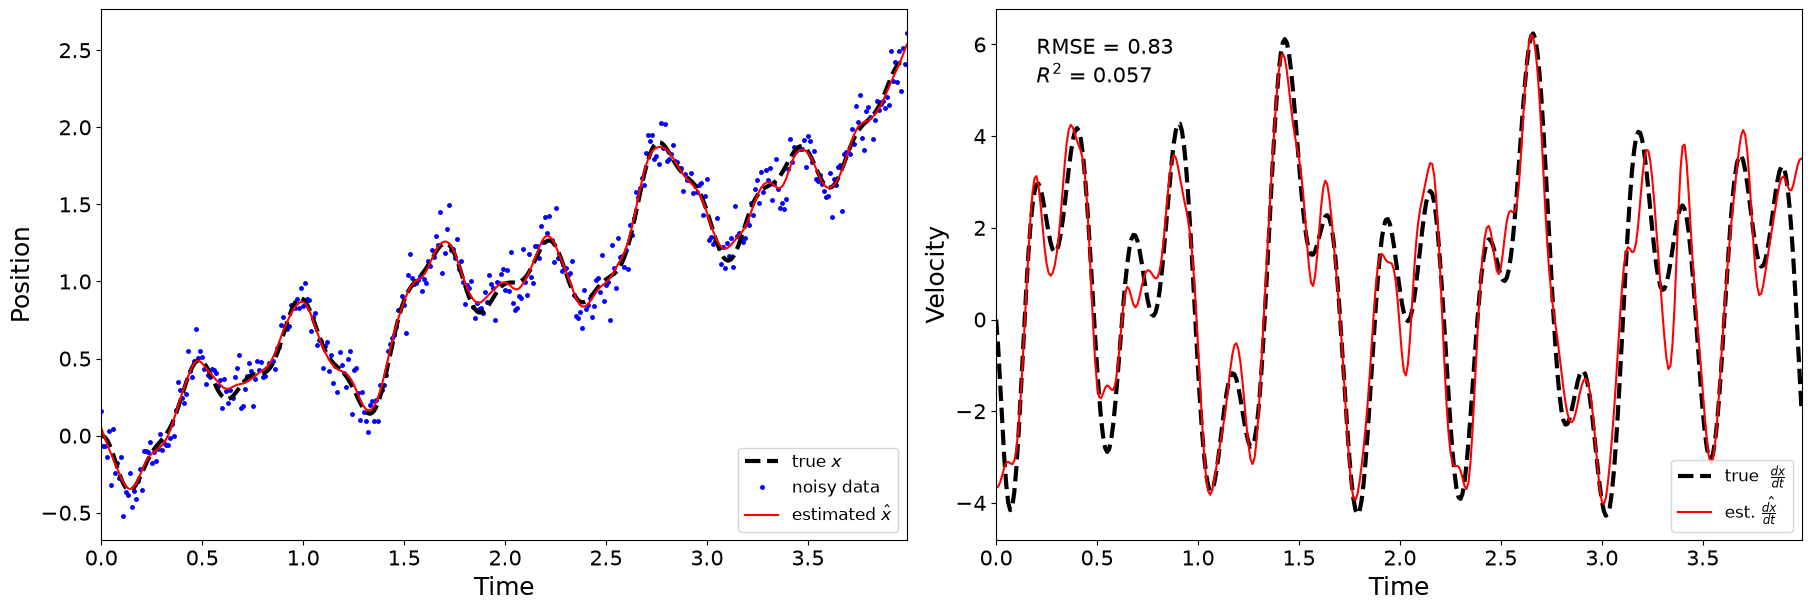

In [6]:
params, val = optimize(finitediff, x, dt, dxdt_truth=dxdt_truth)
print('Optimal parameters:', params)
x_hat, dxdt_hat = finitediff(x, dt, **params)
evaluate.plot(x, dt, x_hat, dxdt_hat, x_truth, dxdt_truth);

params, val = optimize(finitediff, x, dt, bandlimit=bandlimit)
print('Optimal parameters:', params, 'loss:', val)
x_hat, dxdt_hat = finitediff(x, dt, **params)
evaluate.plot(x, dt, x_hat, dxdt_hat, x_truth, dxdt_truth);

## 3. Polynomial-Based Methods

### 3.1 Sliding polynomial fit

optimize(polydiff) took 1.88s
Optimal parameters: {'step_size': 2, 'degree': 3, 'window_size': 37, 'kernel': 'friedrichs'}
optimize(polydiff) took 3.10s
Optimal parameters: {'step_size': 1, 'degree': 2, 'window_size': 23, 'kernel': 'gaussian'} loss: 0.10546546902641797


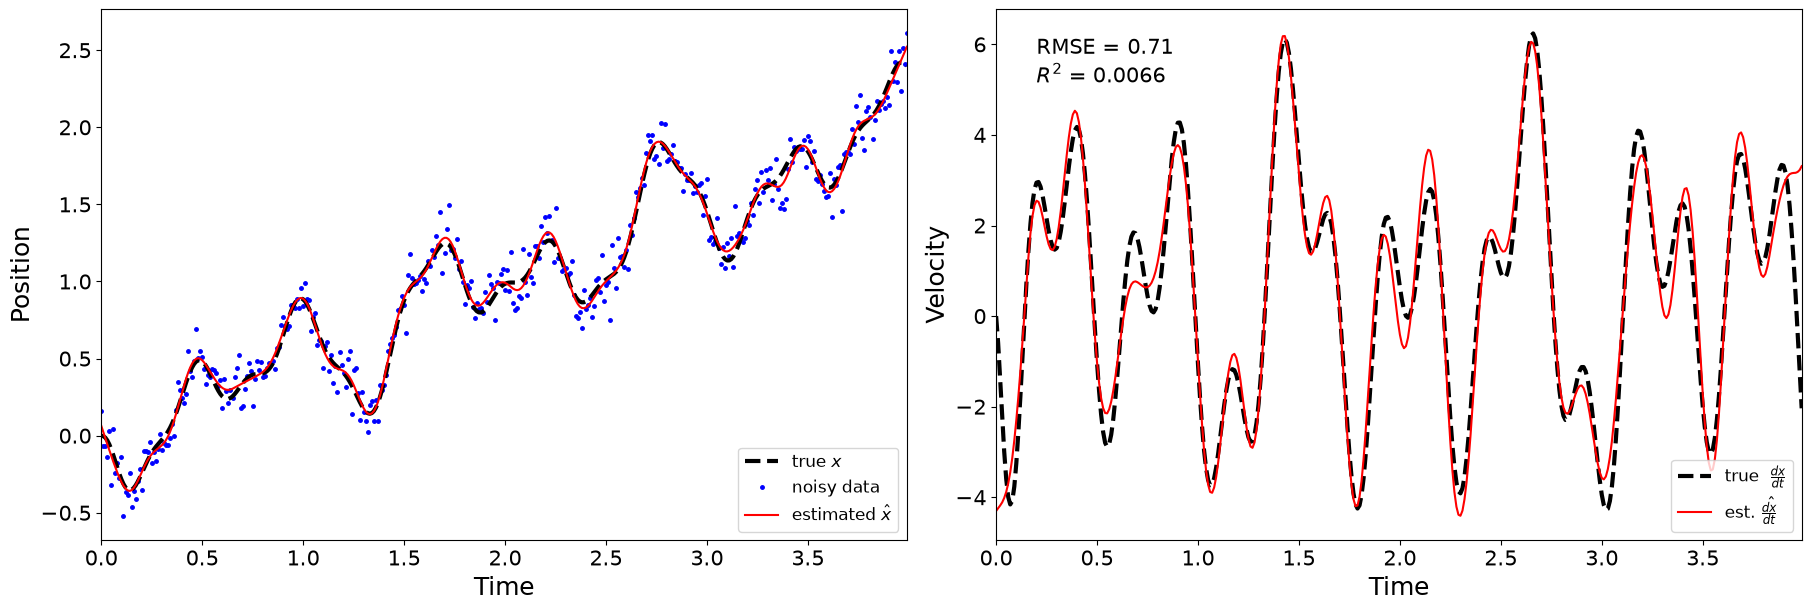

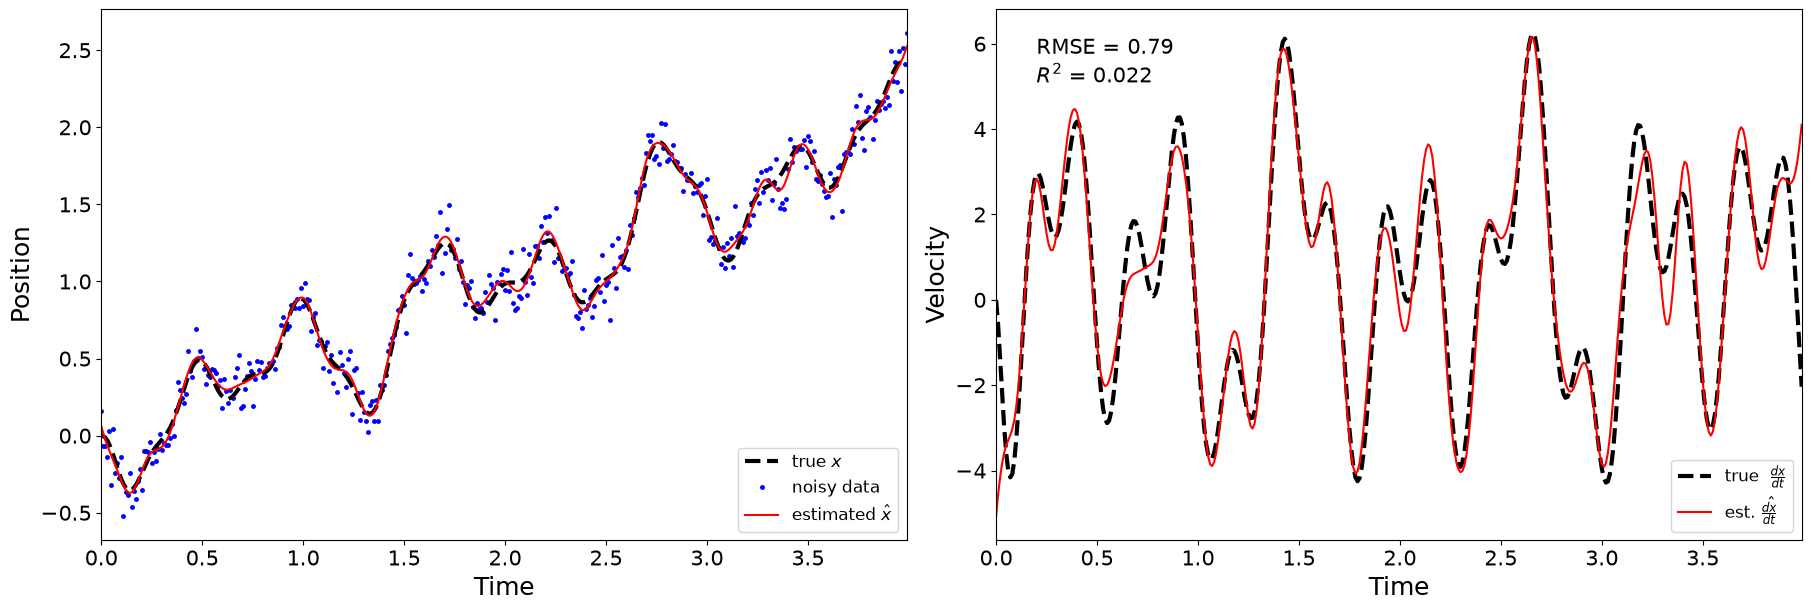

In [7]:
params, val = optimize(polydiff, x, dt, dxdt_truth=dxdt_truth)
print('Optimal parameters:', params)
x_hat, dxdt_hat = polydiff(x, dt, **params)
evaluate.plot(x, dt, x_hat, dxdt_hat, x_truth, dxdt_truth);

params, val = optimize(polydiff, x, dt, bandlimit=bandlimit, search_space_updates={'step_size':[1, 2, 5]})
print('Optimal parameters:', params, 'loss:', val)
x_hat, dxdt_hat = polydiff(x, dt, **params)
evaluate.plot(x, dt, x_hat, dxdt_hat, x_truth, dxdt_truth);

### 3.2 Savitzky-Golay filter

optimize(savgoldiff) took 5.06s
Optimal parameters: {'degree': 7, 'window_size': 59, 'smoothing_win': 11}
optimize(savgoldiff) took 5.29s
Optimal parameters: {'degree': 3, 'window_size': 19, 'smoothing_win': 13} loss: 0.10543523488717466


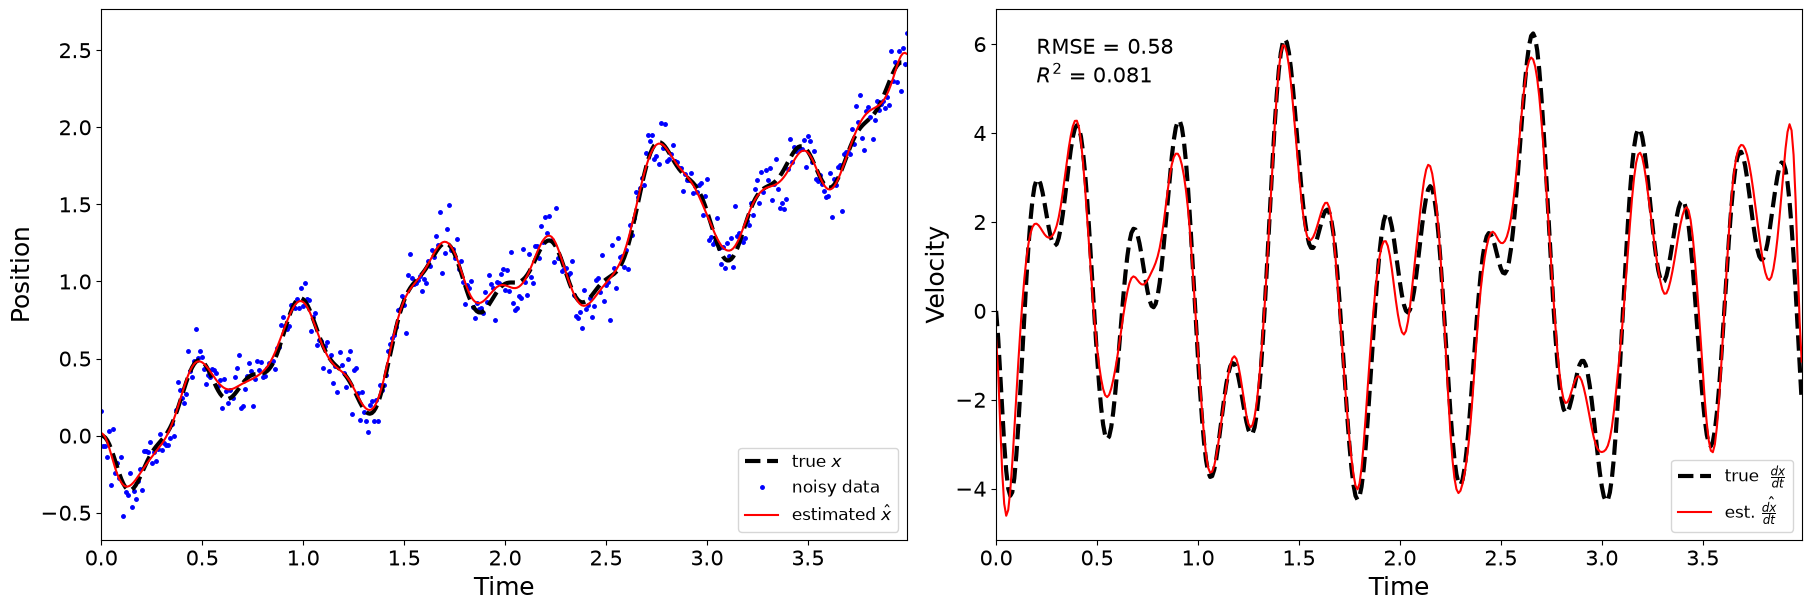

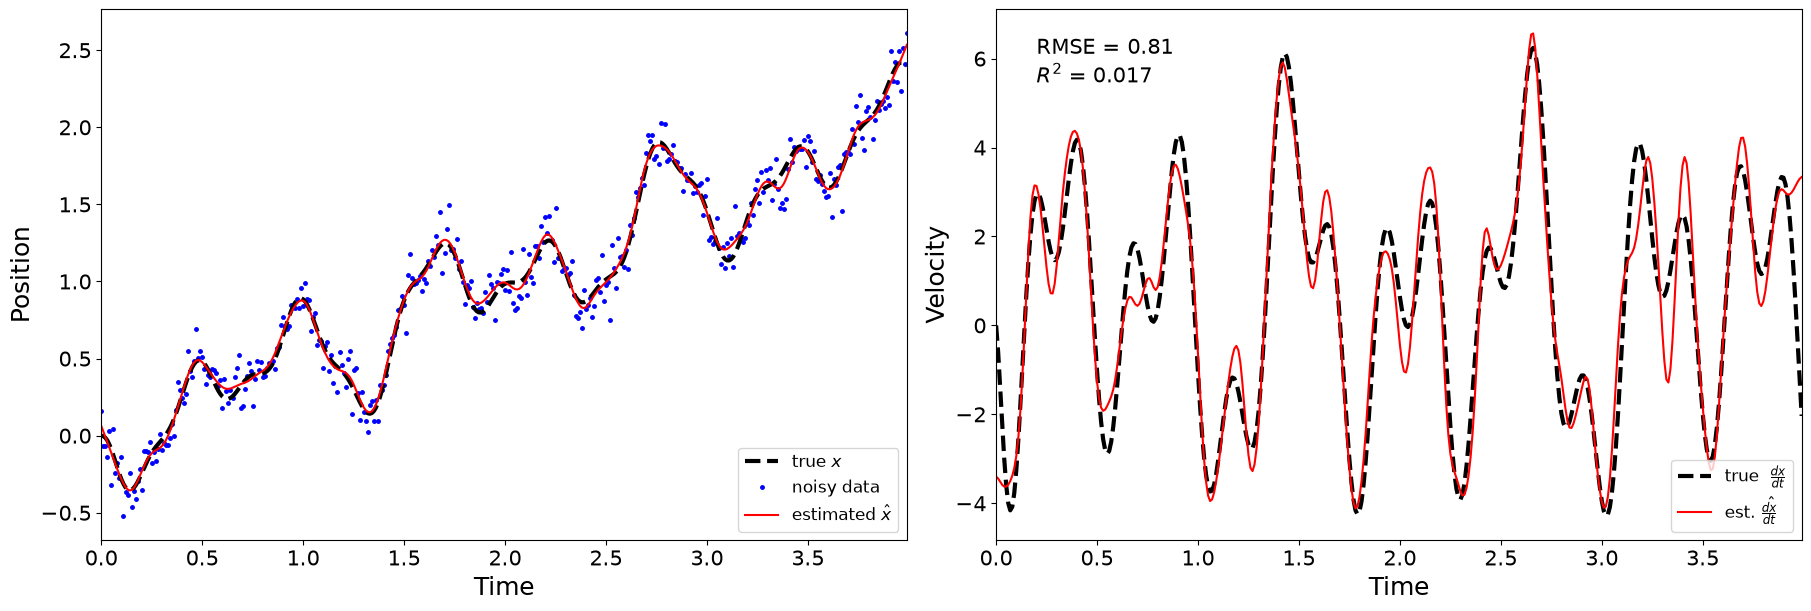

In [8]:
params, val = optimize(savgoldiff, x, dt, dxdt_truth=dxdt_truth)
print('Optimal parameters:', params)
x_hat, dxdt_hat = savgoldiff(x, dt, **params)
evaluate.plot(x, dt, x_hat, dxdt_hat, x_truth, dxdt_truth);

params, val = optimize(savgoldiff, x, dt, bandlimit=bandlimit)
print('Optimal parameters:', params, 'loss:', val)
x_hat, dxdt_hat = savgoldiff(x, dt, **params)
evaluate.plot(x, dt, x_hat, dxdt_hat, x_truth, dxdt_truth);

### 3.3 Splines

optimize(splinediff) took 1.94s
Optimal parameters: {'s': np.float64(0.8999999999999986), 'num_iterations': 1, 'degree': 5}
optimize(splinediff) took 2.53s
Optimal parameters: {'s': np.float64(0.8749999999999982), 'num_iterations': 1, 'degree': 5} loss: 0.10787629002873017


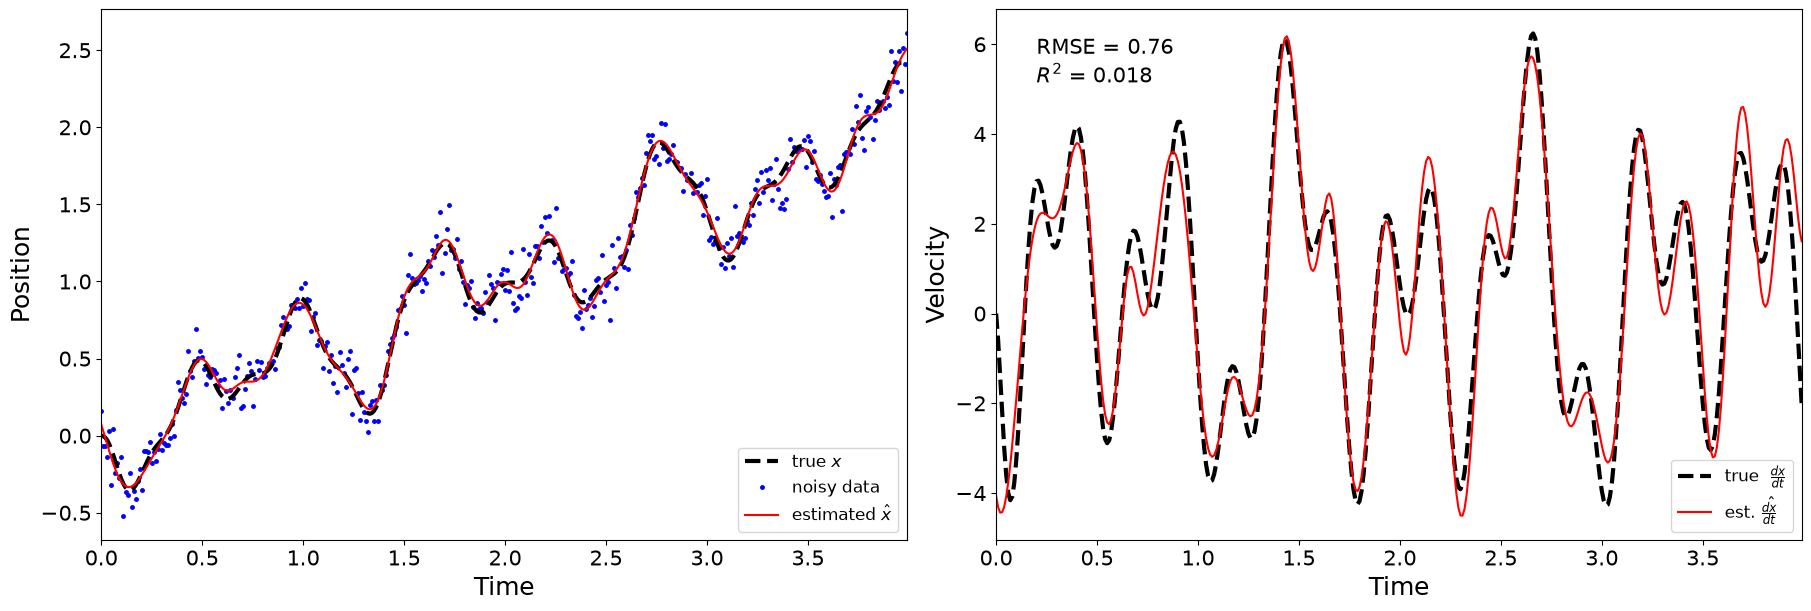

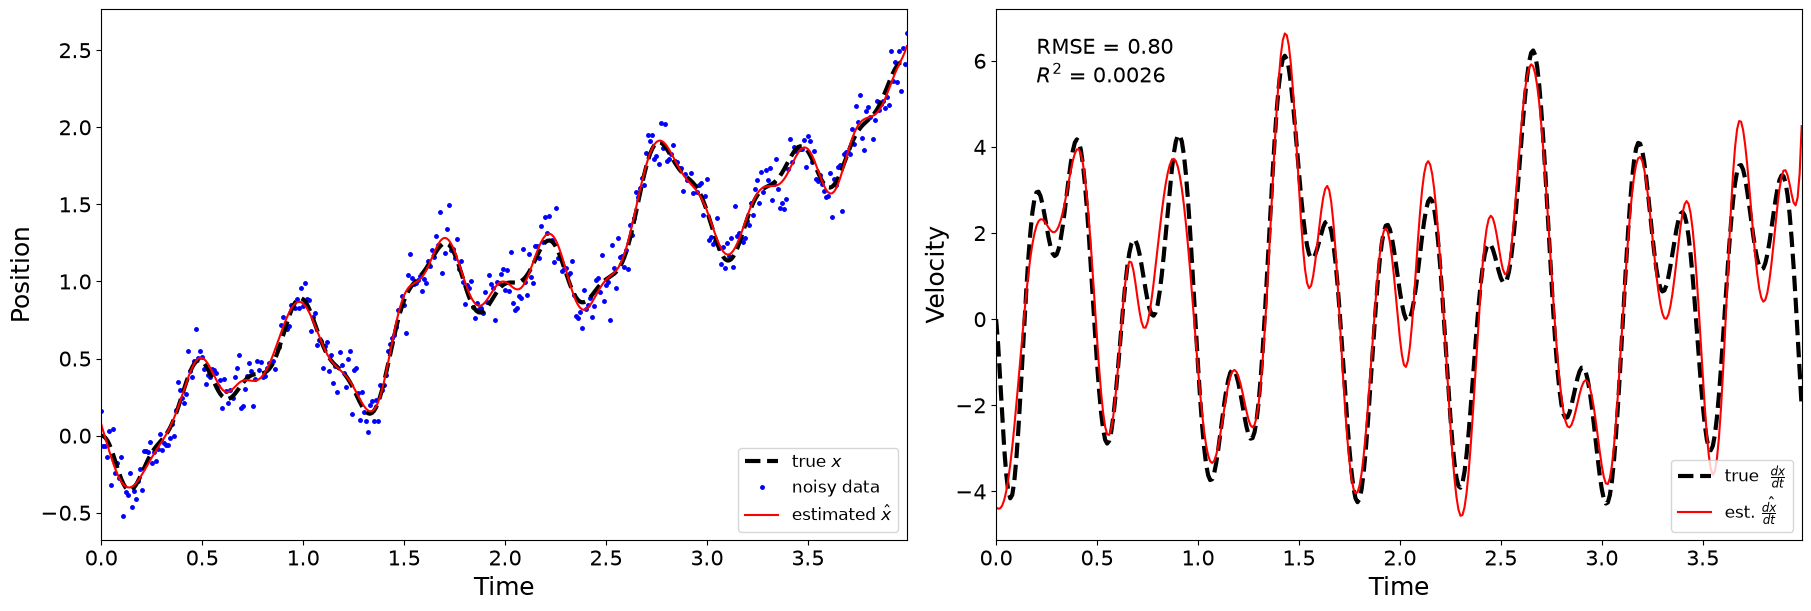

In [9]:
params, val = optimize(splinediff, x, dt, dxdt_truth=dxdt_truth)
print('Optimal parameters:', params)
x_hat, dxdt_hat = splinediff(x, dt, **params)
evaluate.plot(x, dt, x_hat, dxdt_hat, x_truth, dxdt_truth);

params, val = optimize(splinediff, x, dt, bandlimit=bandlimit)
print('Optimal parameters:', params, 'loss:', val)
x_hat, dxdt_hat = splinediff(x, dt, **params)
evaluate.plot(x, dt, x_hat, dxdt_hat, x_truth, dxdt_truth);

## 4. Basis-Function-Based Methods

### 4.1 Spectral Derivative with Tricks

optimize(spectraldiff) took 1.44s
Optimal parameters: {'cutoff_freq': np.float64(0.08250000000000005), 'even_extension': True, 'pad_to_zero_dxdt': False}
optimize(spectraldiff) took 1.58s
Optimal parameters: {'cutoff_freq': np.float64(0.1), 'even_extension': True, 'pad_to_zero_dxdt': True} loss: 0.10800535140520728


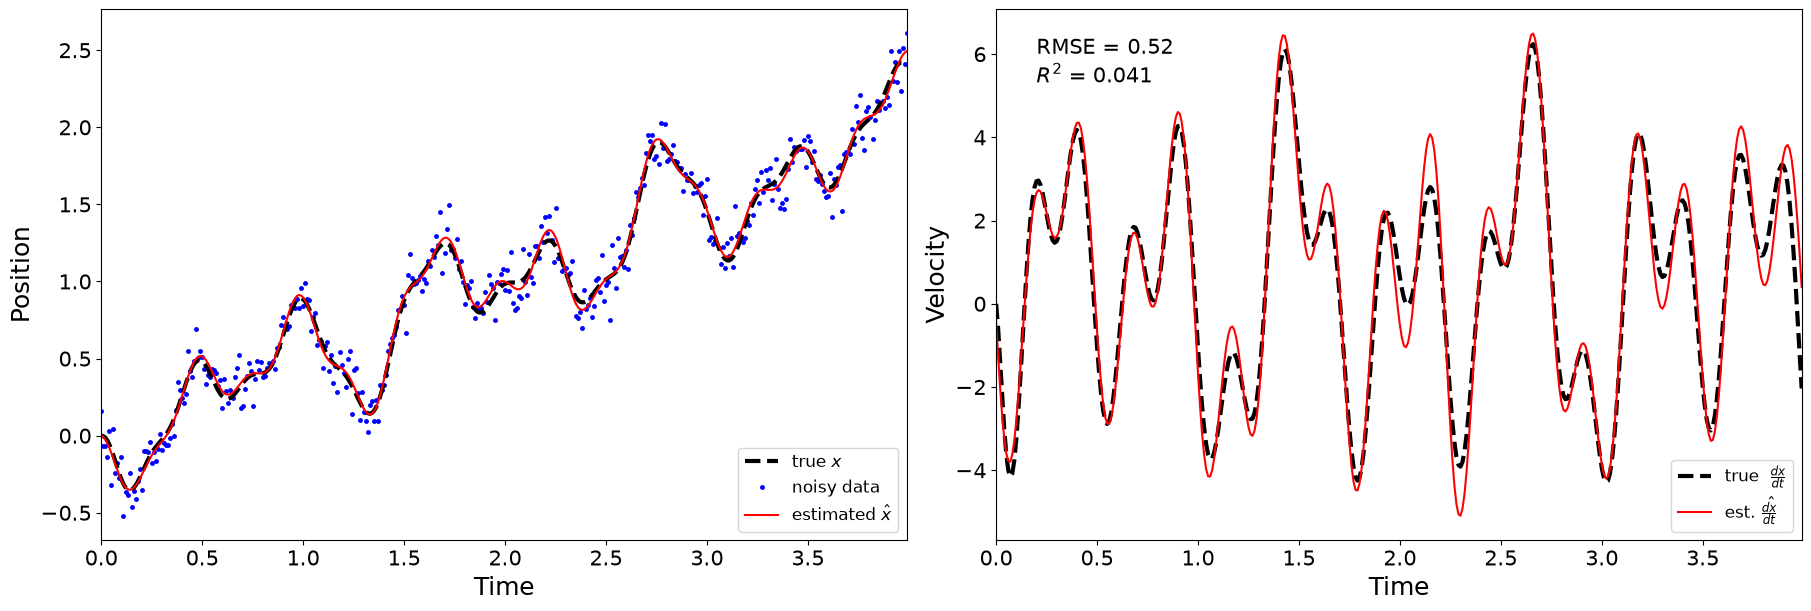

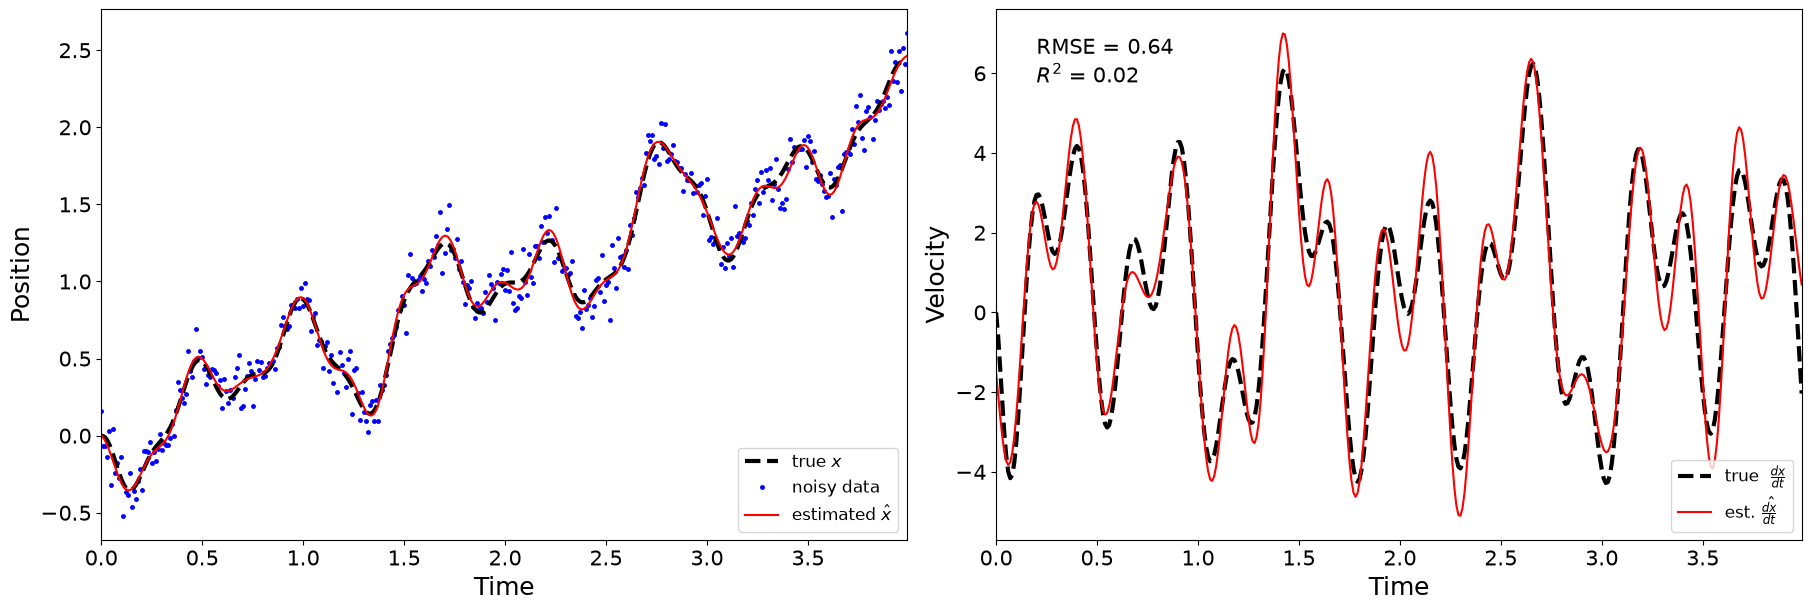

In [10]:
params, val = optimize(spectraldiff, x, dt, dxdt_truth=dxdt_truth)
print('Optimal parameters:', params)
x_hat, dxdt_hat = spectraldiff(x, dt, **params)
evaluate.plot(x, dt, x_hat, dxdt_hat, x_truth, dxdt_truth);

params, val = optimize(spectraldiff, x, dt, bandlimit=bandlimit)
print('Optimal parameters:', params, 'loss:', val)
x_hat, dxdt_hat = spectraldiff(x, dt, **params)
evaluate.plot(x, dt, x_hat, dxdt_hat, x_truth, dxdt_truth);

### 4.2 Radial Basis Functions

Fit and differentiate a local basis.

optimize(rbfdiff) took 4.67s
Optimal parameters: {'sigma': np.float64(0.11398925781249991), 'lmbd': np.float64(0.11673339843749997)}
optimize(rbfdiff) took 4.17s
Optimal parameters: {'sigma': np.float64(0.1265624999999999), 'lmbd': np.float64(0.04875000000000007)} loss: 0.10697993872989803


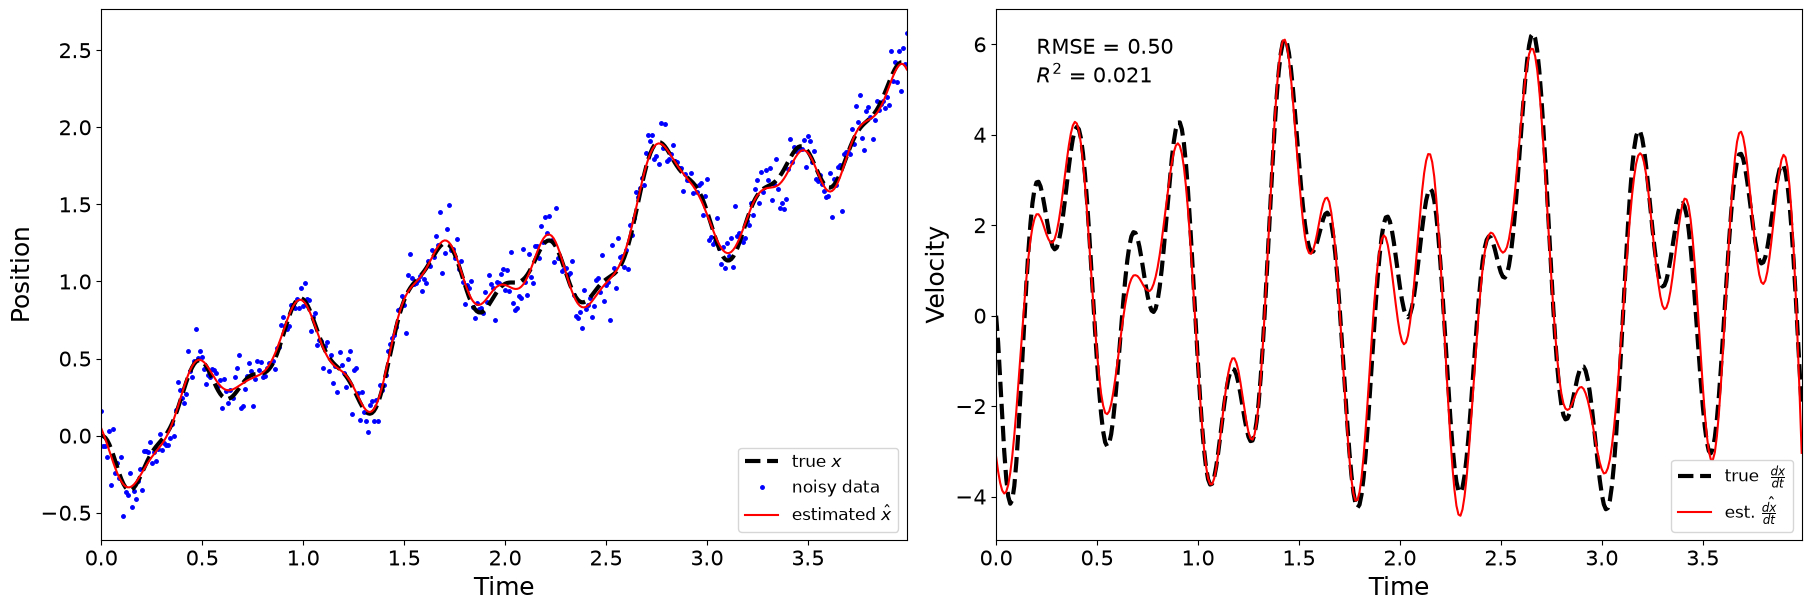

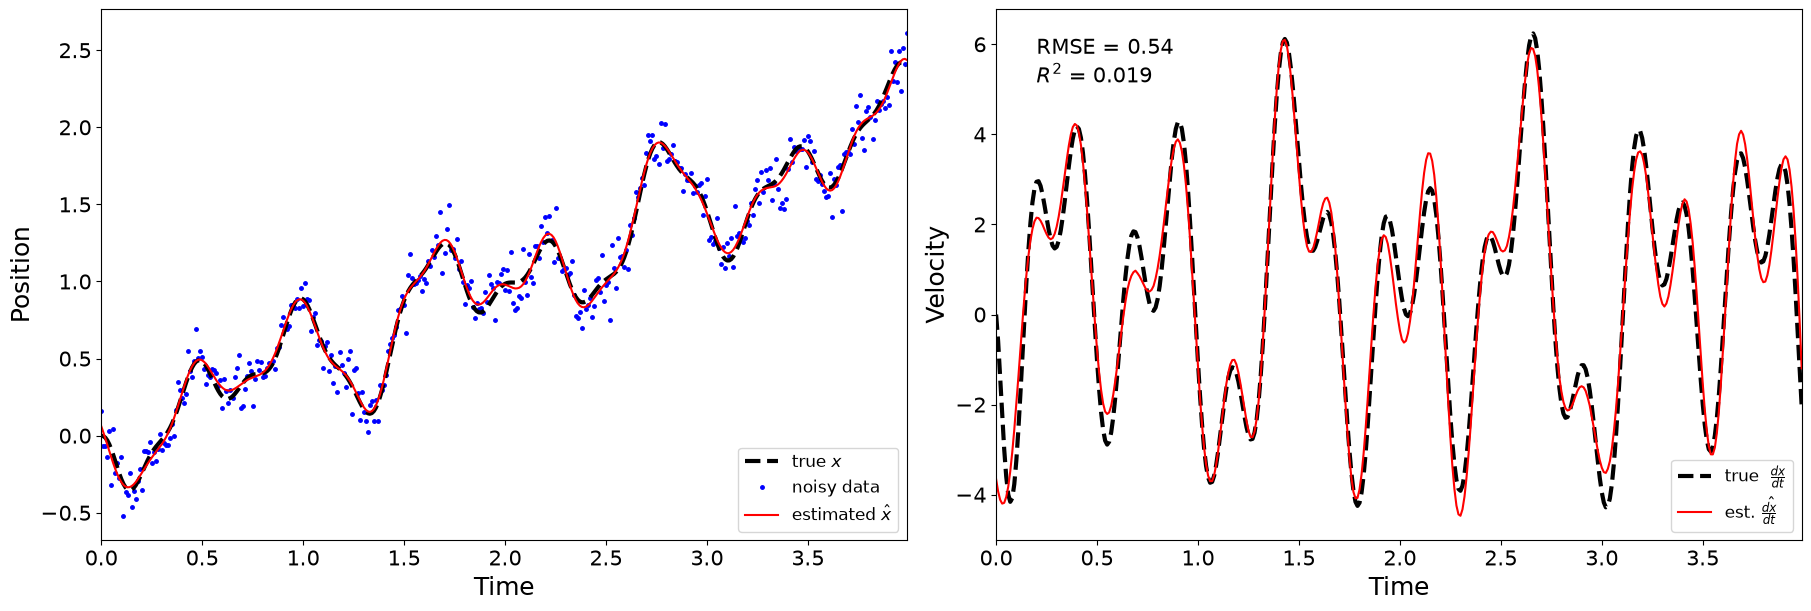

In [11]:
params, val = optimize(rbfdiff, x, dt, dxdt_truth=dxdt_truth)
print('Optimal parameters:', params)
x_hat, dxdt_hat = rbfdiff(x, dt, **params)
evaluate.plot(x, dt, x_hat, dxdt_hat, x_truth, dxdt_truth);

params, val = optimize(rbfdiff, x, dt, bandlimit=bandlimit)
print('Optimal parameters:', params, 'loss:', val)
x_hat, dxdt_hat = rbfdiff(x, dt, **params)
evaluate.plot(x, dt, x_hat, dxdt_hat, x_truth, dxdt_truth);

### 4.3 Wavelets

Shrink detail coefficients in a wavelet basis, then differentiate.

optimize(waveletdiff) took 1.49s
Optimal parameters: {'threshold': np.float64(0.7617187499999998), 'wavelet': 'sym8'}
optimize(waveletdiff) took 1.60s
Optimal parameters: {'threshold': np.float64(0.818750000000001), 'wavelet': 'sym8'} loss: 0.11556380026281632


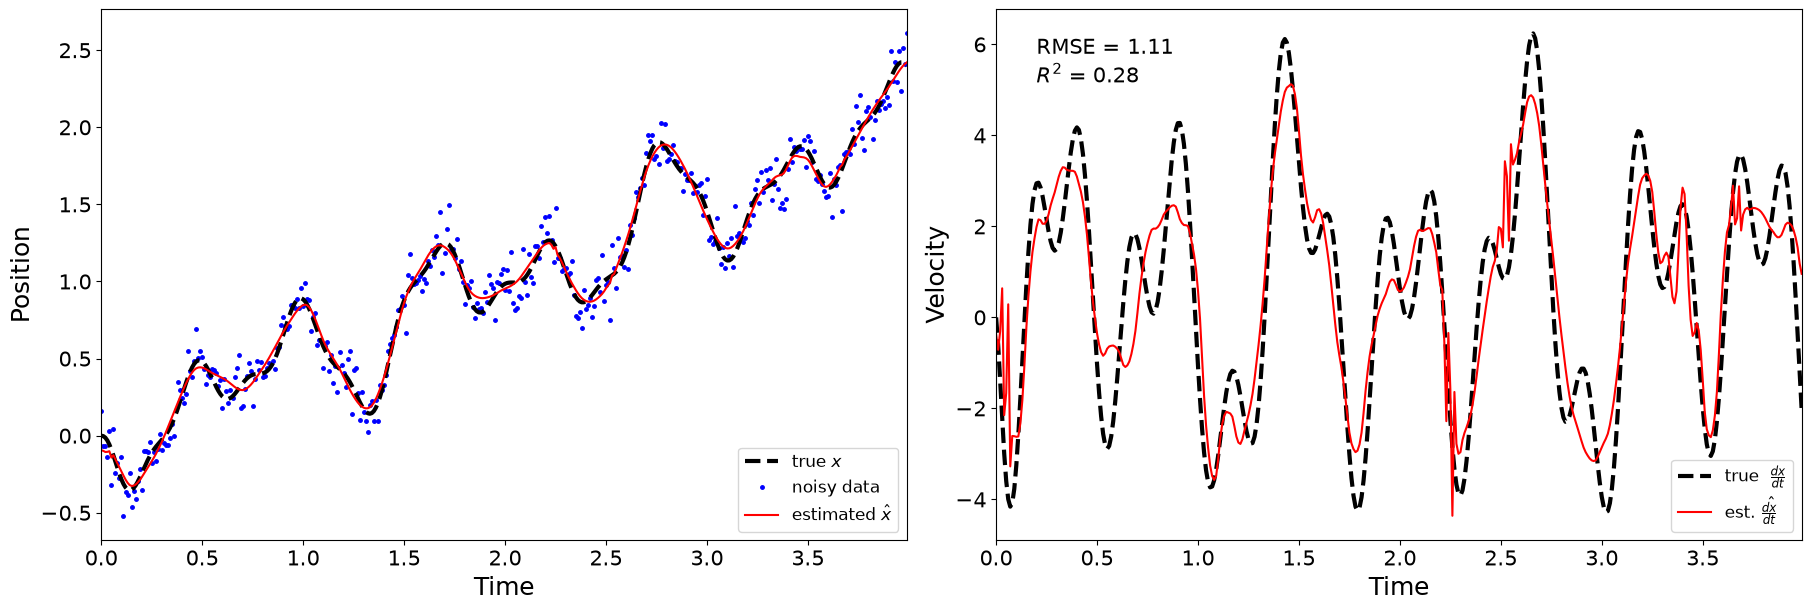

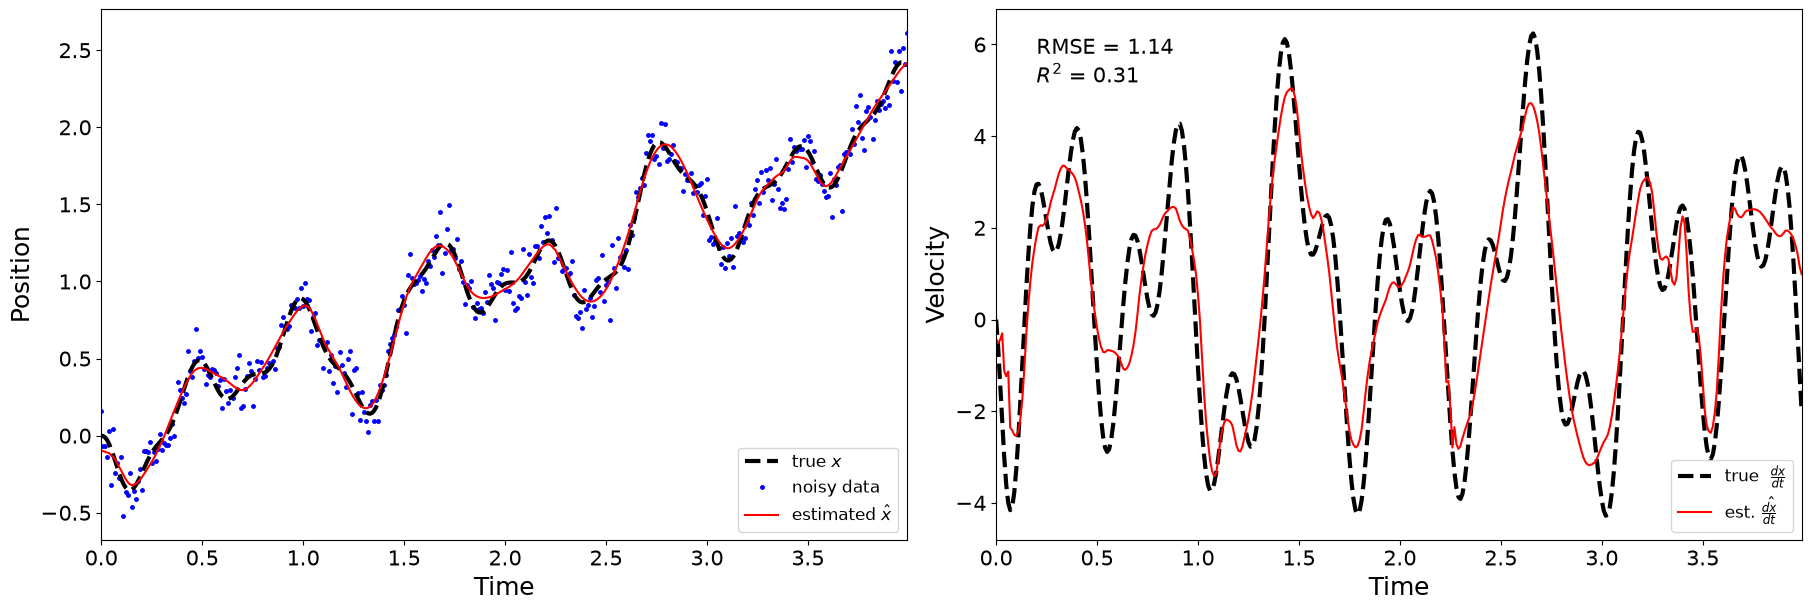

In [12]:
params, val = optimize(waveletdiff, x, dt, dxdt_truth=dxdt_truth)
print('Optimal parameters:', params)
x_hat, dxdt_hat = waveletdiff(x, dt, **params)
evaluate.plot(x, dt, x_hat, dxdt_hat, x_truth, dxdt_truth);

params, val = optimize(waveletdiff, x, dt, bandlimit=bandlimit)
print('Optimal parameters:', params, 'loss:', val)
x_hat, dxdt_hat = waveletdiff(x, dt, **params)
evaluate.plot(x, dt, x_hat, dxdt_hat, x_truth, dxdt_truth);

## 5. Total Variation Regularization

### 5.1 Convex TVRed Derivative

optimize(tvrdiff) took 10.01s
Optimal parameters: {'gamma': np.float64(7.6015625), 'huberM': np.float64(4.974609374999995), 'order': 3}
optimize(tvrdiff) took 7.07s
Optimal parameters: {'gamma': np.float64(9.34375), 'huberM': np.float64(5.578124999999998), 'order': 3} loss: 0.10545716647230129


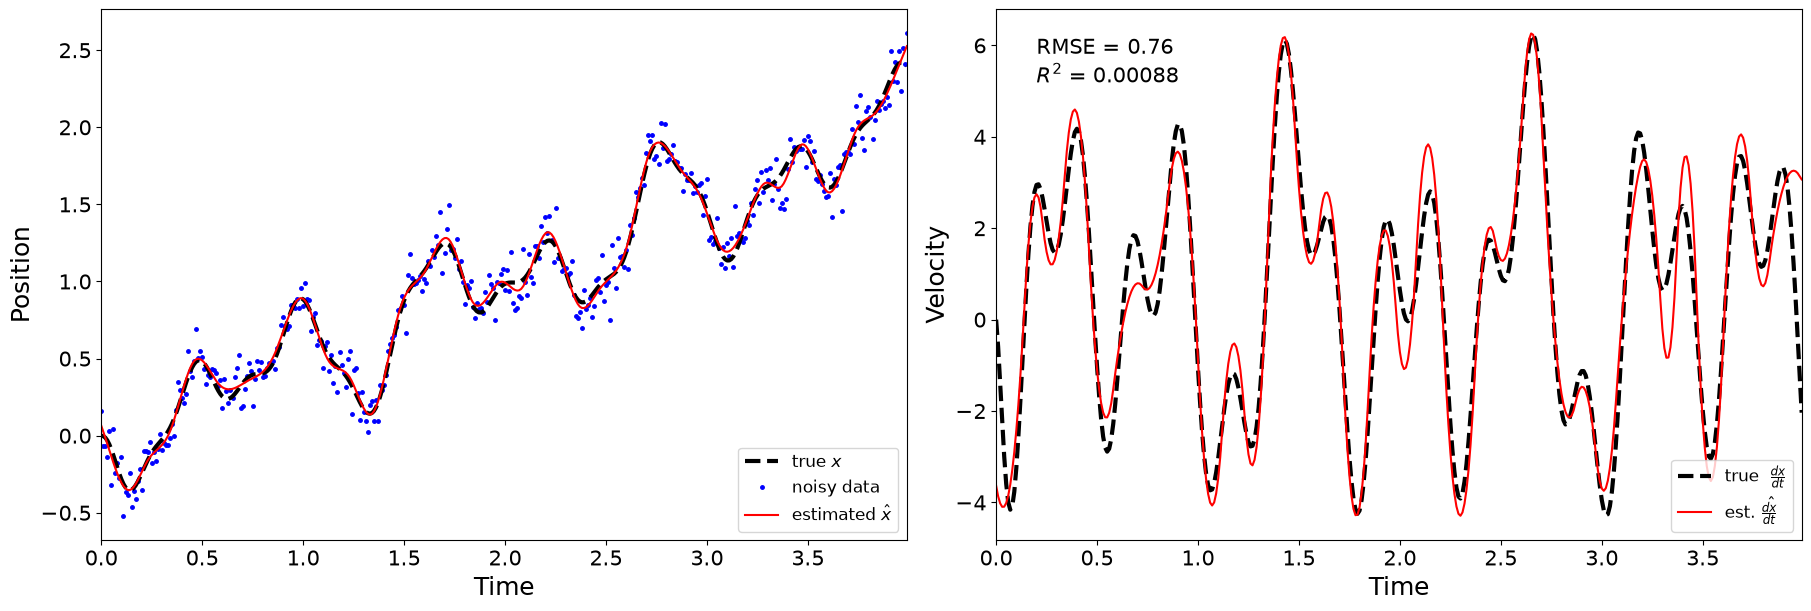

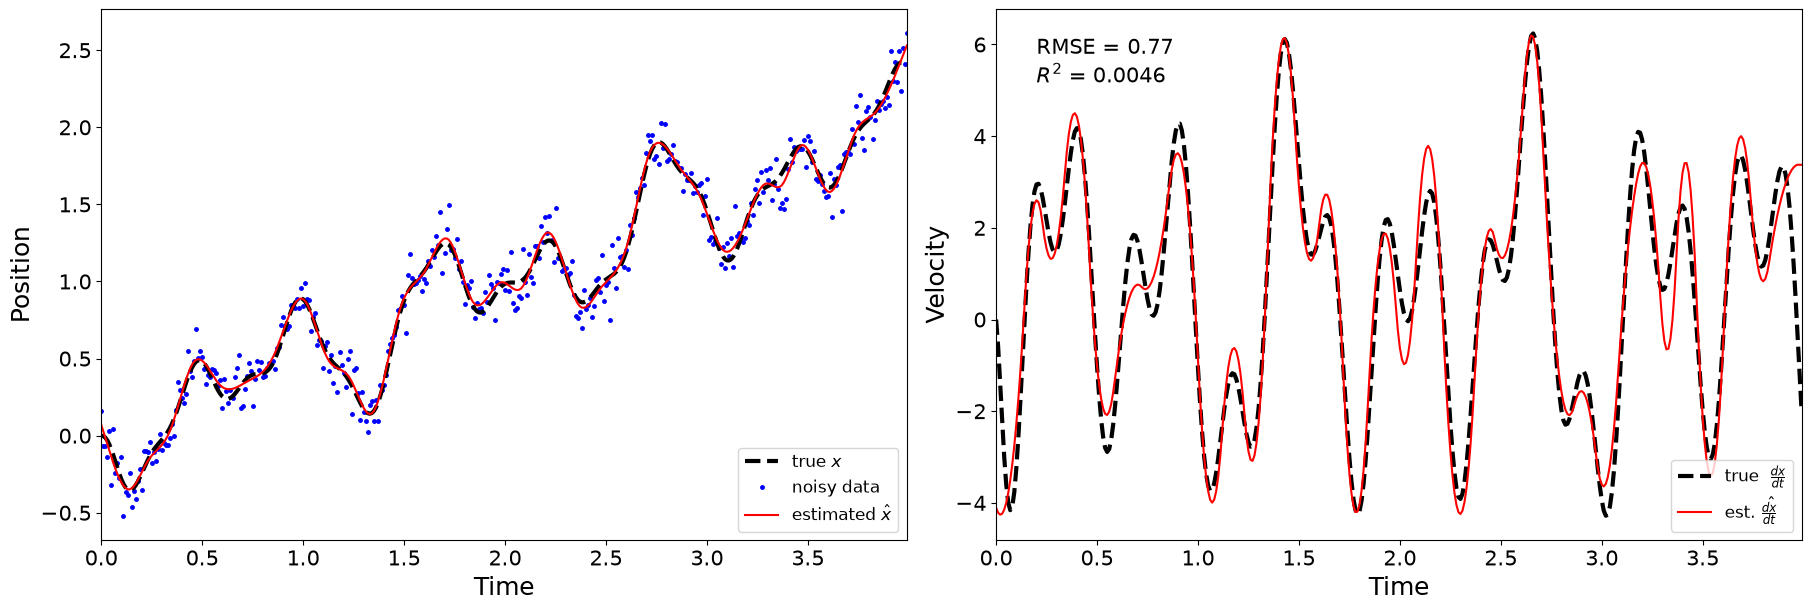

In [13]:
params, val = optimize(tvrdiff, x, dt, dxdt_truth=dxdt_truth)
print('Optimal parameters:', params)
x_hat, dxdt_hat = tvrdiff(x, dt, **params)
evaluate.plot(x, dt, x_hat, dxdt_hat, x_truth, dxdt_truth);

params, val = optimize(tvrdiff, x, dt, bandlimit=bandlimit, search_space_updates={'order':{2,3}})
print('Optimal parameters:', params, 'loss:', val)
x_hat, dxdt_hat = tvrdiff(x, dt, **params)
evaluate.plot(x, dt, x_hat, dxdt_hat, x_truth, dxdt_truth);

### 5.2 TVR acceleration with gaussian smoothing

optimize(smooth_acceleration) took 5.97s
Optimal parameters: {'gamma': np.float64(0.9753906249999988), 'window_size': 17}
optimize(smooth_acceleration) took 6.11s
Optimal parameters: {'gamma': np.float64(0.8499999999999999), 'window_size': 13} loss: 0.10529108774627939


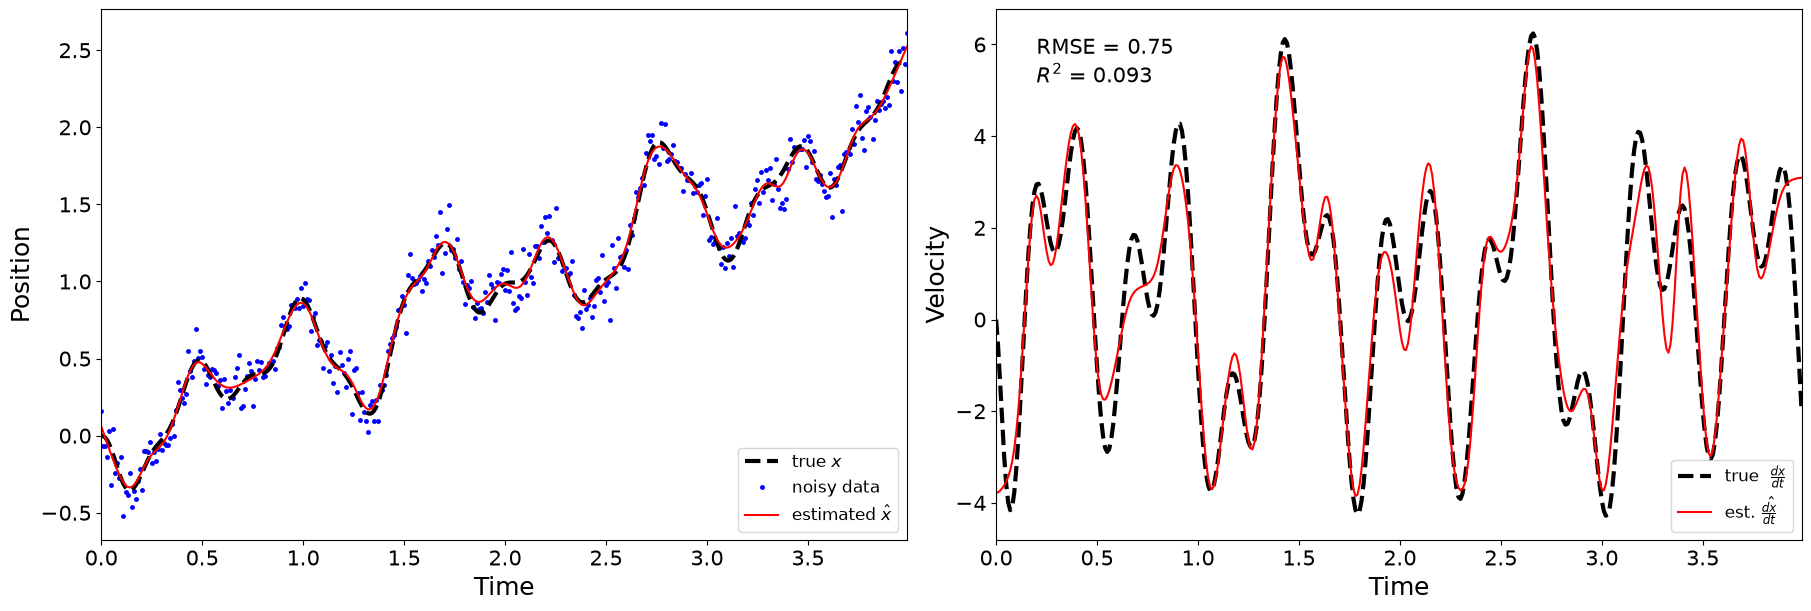

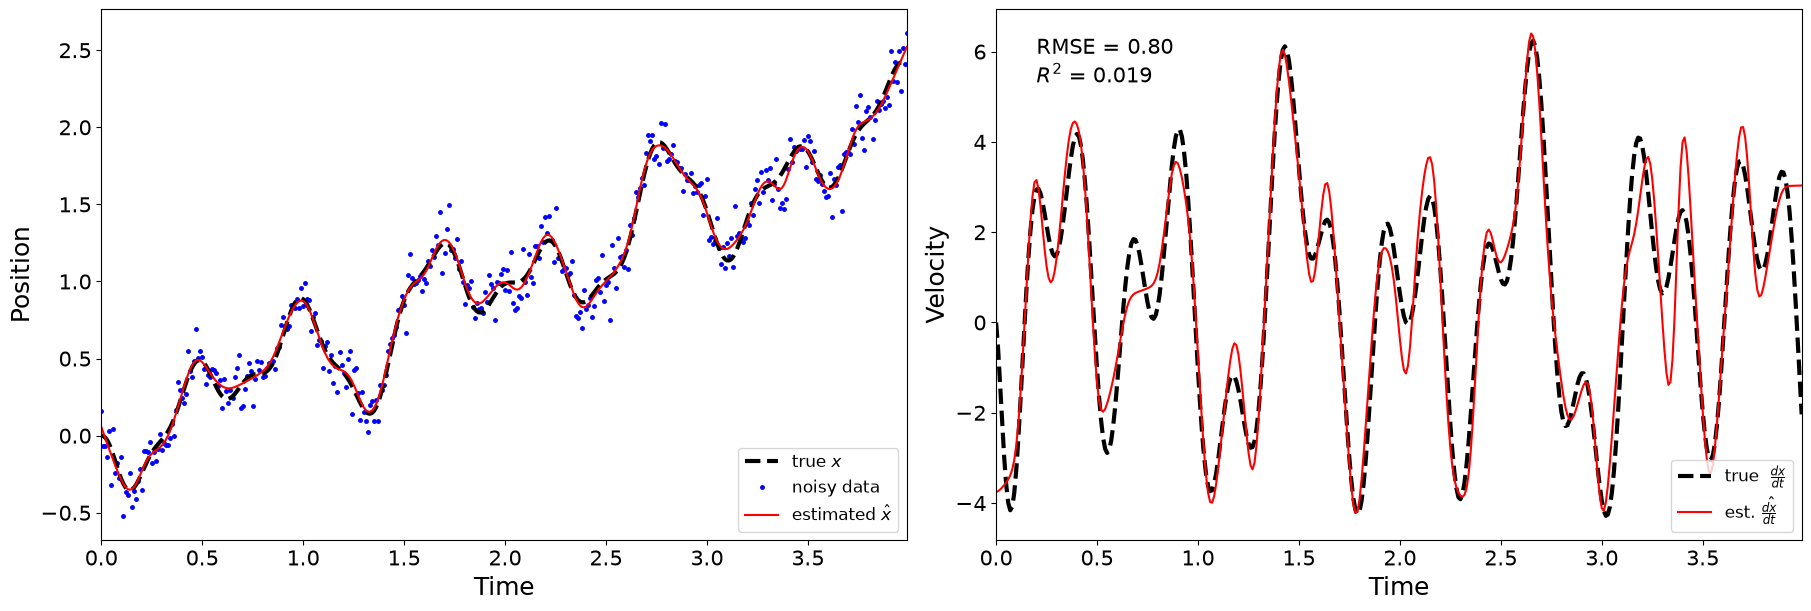

In [14]:
params, val = optimize(smooth_acceleration, x, dt, dxdt_truth=dxdt_truth)
print('Optimal parameters:', params)
x_hat, dxdt_hat = smooth_acceleration(x, dt, **params)
evaluate.plot(x, dt, x_hat, dxdt_hat, x_truth, dxdt_truth);

params, val = optimize(smooth_acceleration, x, dt, bandlimit=bandlimit)
print('Optimal parameters:', params, 'loss:', val)
x_hat, dxdt_hat = smooth_acceleration(x, dt, **params)
evaluate.plot(x, dt, x_hat, dxdt_hat, x_truth, dxdt_truth);

## 6. Kalman smoothing

### 6.1 RTS Smoothing

optimize(rtsdiff) took 3.09s
Optimal parameters: {'log_qr_ratio': np.float64(9.949999999999996), 'order': 3, 'forwardbackward': True}
optimize(rtsdiff) took 3.50s
Optimal parameters: {'log_qr_ratio': np.float64(4.1875), 'order': 1, 'forwardbackward': False} loss: 0.10484462444735851


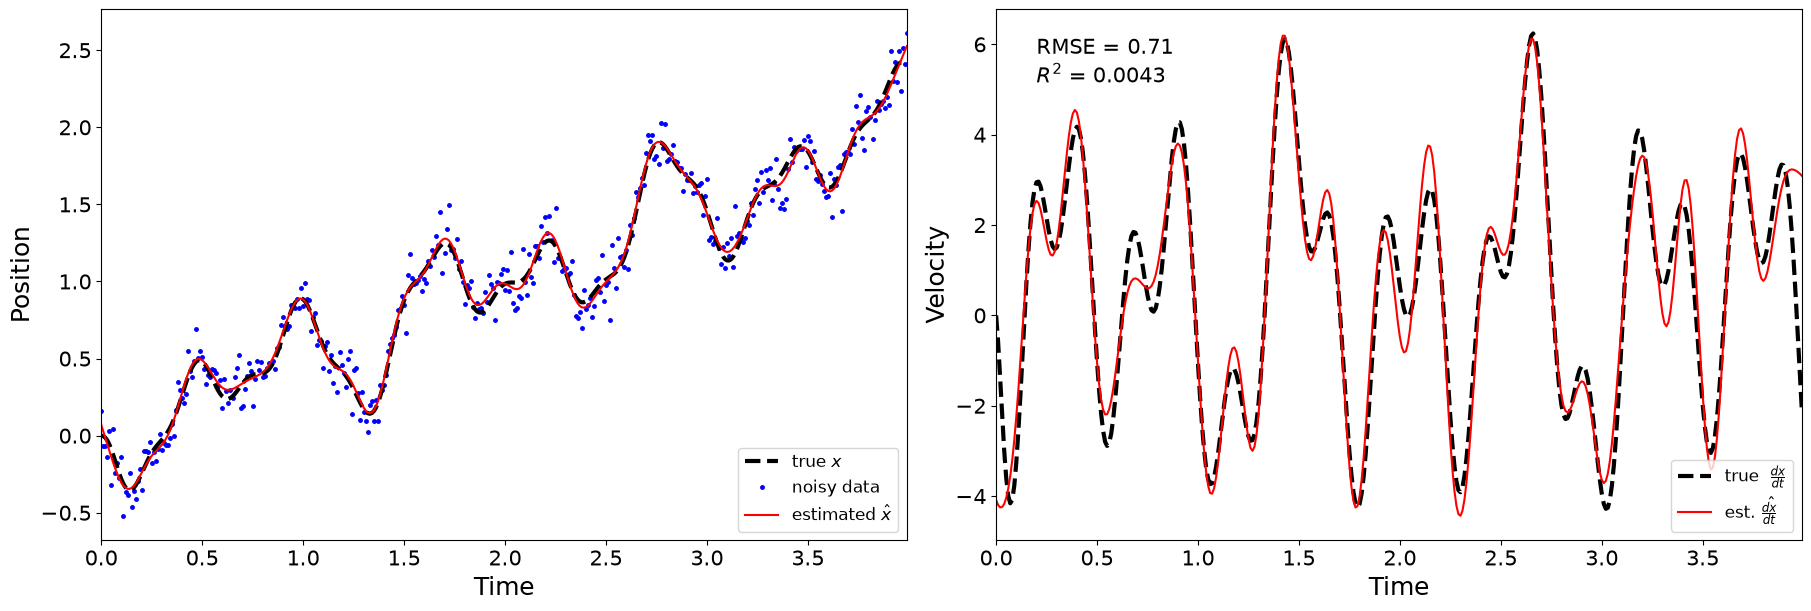

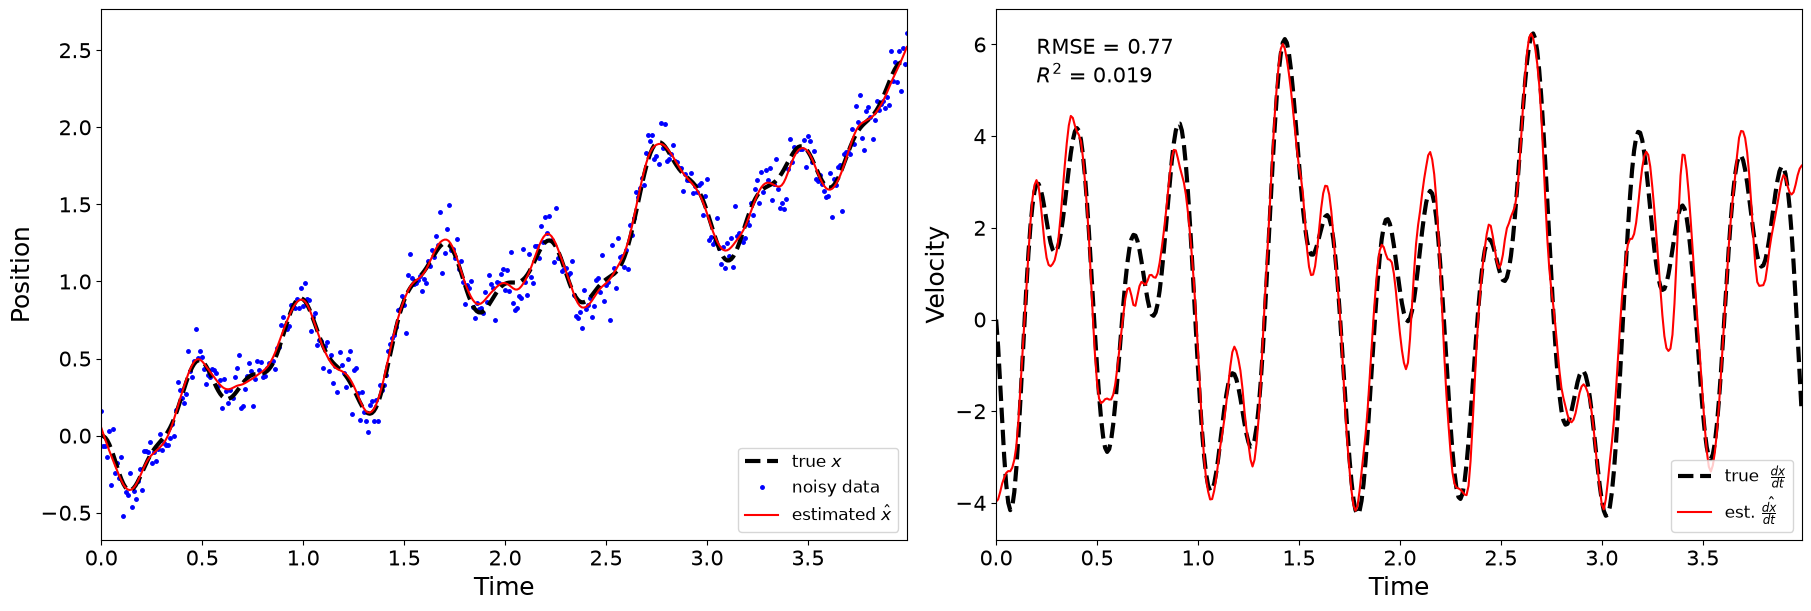

In [15]:
params, val = optimize(rtsdiff, x, dt, dxdt_truth=dxdt_truth)
print('Optimal parameters:', params)
x_hat, dxdt_hat = rtsdiff(x, dt, **params)
evaluate.plot(x, dt, x_hat, dxdt_hat, x_truth, dxdt_truth);

params, val = optimize(rtsdiff, x, dt, bandlimit=bandlimit)
print('Optimal parameters:', params, 'loss:', val)
x_hat, dxdt_hat = rtsdiff(x, dt, **params)
evaluate.plot(x, dt, x_hat, dxdt_hat, x_truth, dxdt_truth);

### Huber/$\ell_1$ "Robust" Smoothing

The 5-dimensional hyperparameter space makes this one significantly slower to optimize, although `log_r` has a natural set point at 0, so the initial conditions sweep is only over the other 4, with all 5 allowed to wobble around as optimization progresses.

optimize(robustdiff) took 15.63s
Optimal parameters: {'log_q': np.float64(9.9697265625), 'log_r': np.float64(-3.7719726562500074e-05), 'proc_huberM': np.float64(1.9872558593750007), 'meas_huberM': np.float64(2.313037109375002), 'order': 3}
optimize(robustdiff) took 14.34s
Optimal parameters: {'log_q': np.float64(7.175000000000001), 'log_r': np.float64(-0.00025), 'proc_huberM': np.float64(2.05), 'meas_huberM': np.float64(5.85), 'order': 2} cost: 0.10548455139169972


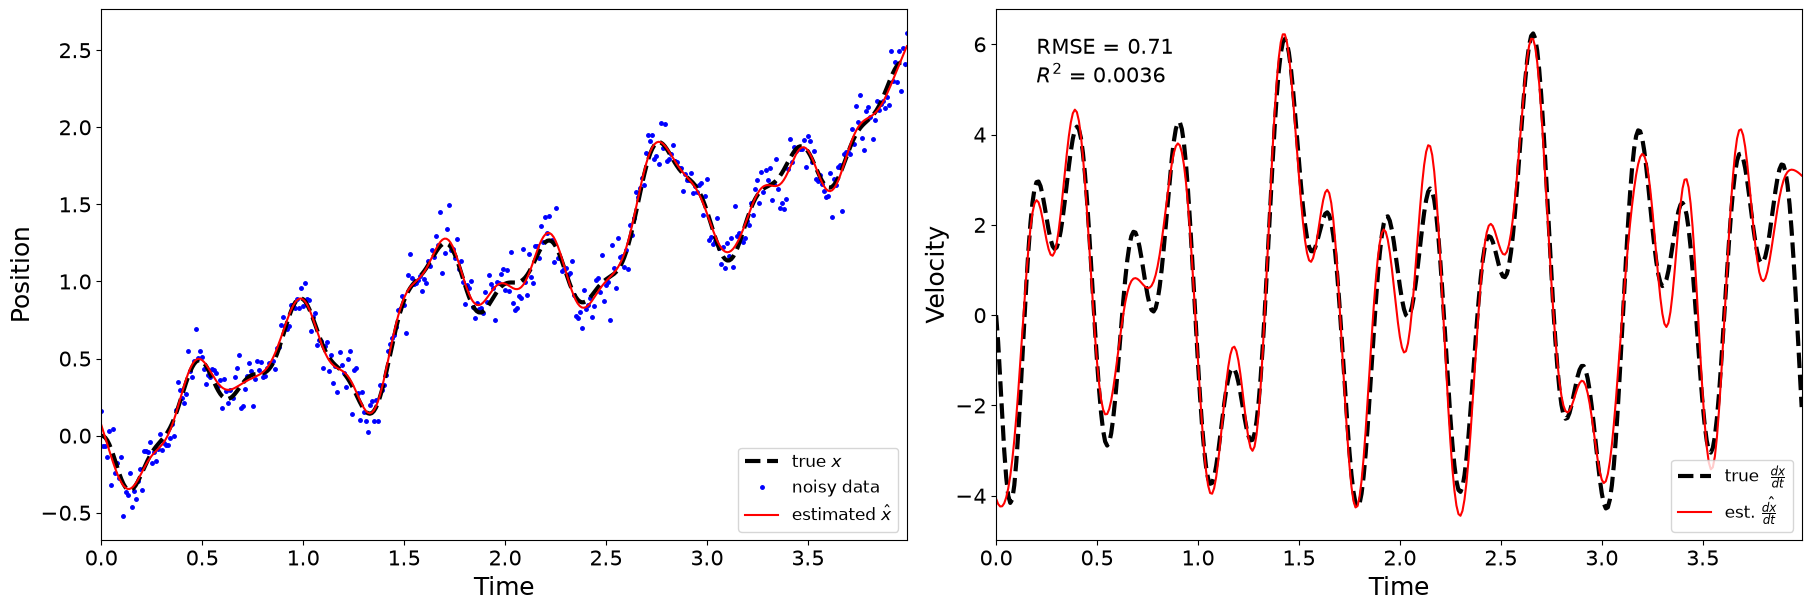

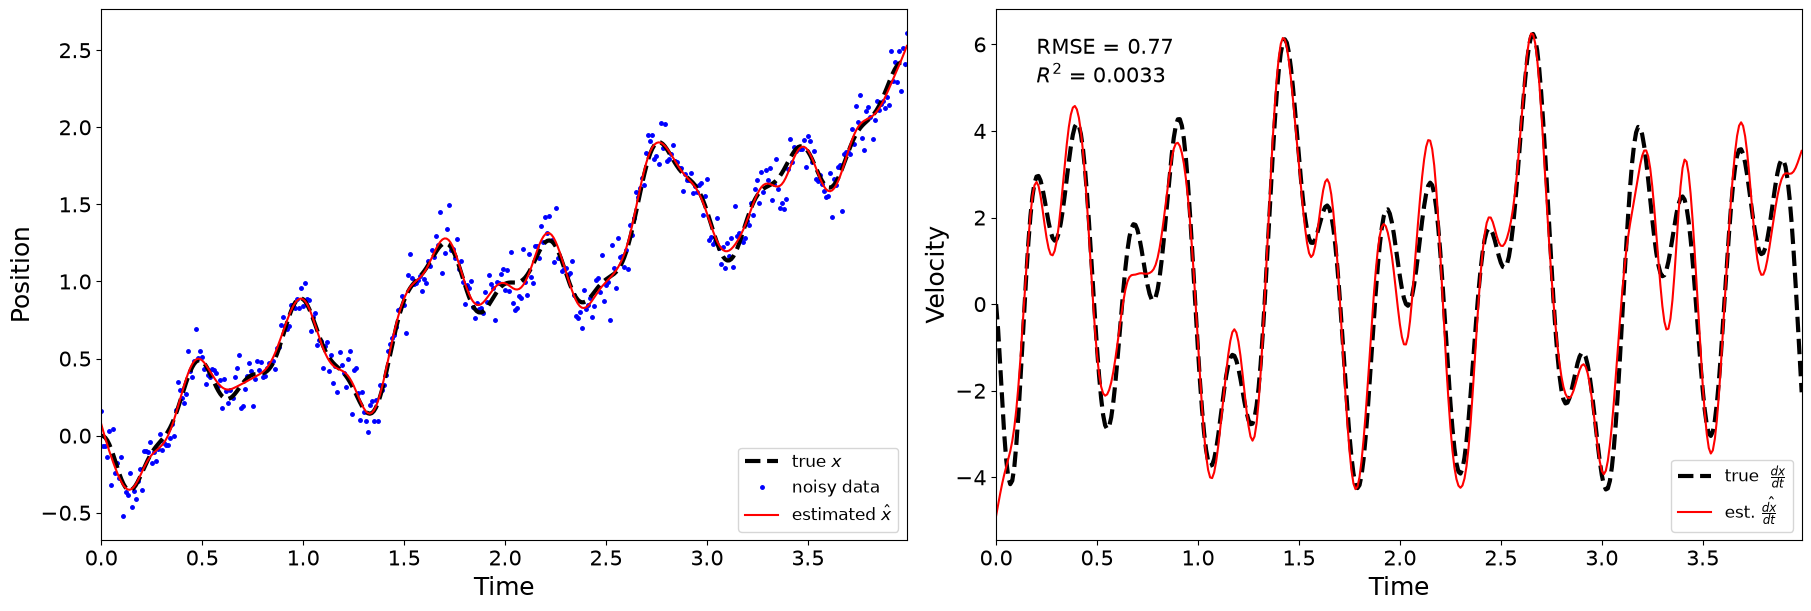

In [16]:
params, val = optimize(robustdiff, x, dt, dxdt_truth=dxdt_truth)
print('Optimal parameters:', params)
x_hat, dxdt_hat = robustdiff(x, dt, **params)
evaluate.plot(x, dt, x_hat, dxdt_hat, x_truth, dxdt_truth);

params, val = optimize(robustdiff, x, dt, bandlimit=bandlimit, search_space_updates={'order':{2,3}})
print('Optimal parameters:', params, 'cost:', val)
x_hat, dxdt_hat = robustdiff(x, dt, **params)
evaluate.plot(x, dt, x_hat, dxdt_hat, x_truth, dxdt_truth);

## 7. Linear Model: Sliding linear time invariant system fit

optimize(lineardiff) took 8.05s
Optimal parameters: {'gamma': np.float64(0.10703124999999988), 'window_size': 27, 'order': 2, 'kernel': 'friedrichs'}
optimize(lineardiff) took 8.66s
Optimal parameters: {'gamma': np.float64(0.009289062499999997), 'window_size': 33, 'order': 2, 'kernel': 'friedrichs'} cost: 0.10612935828671989


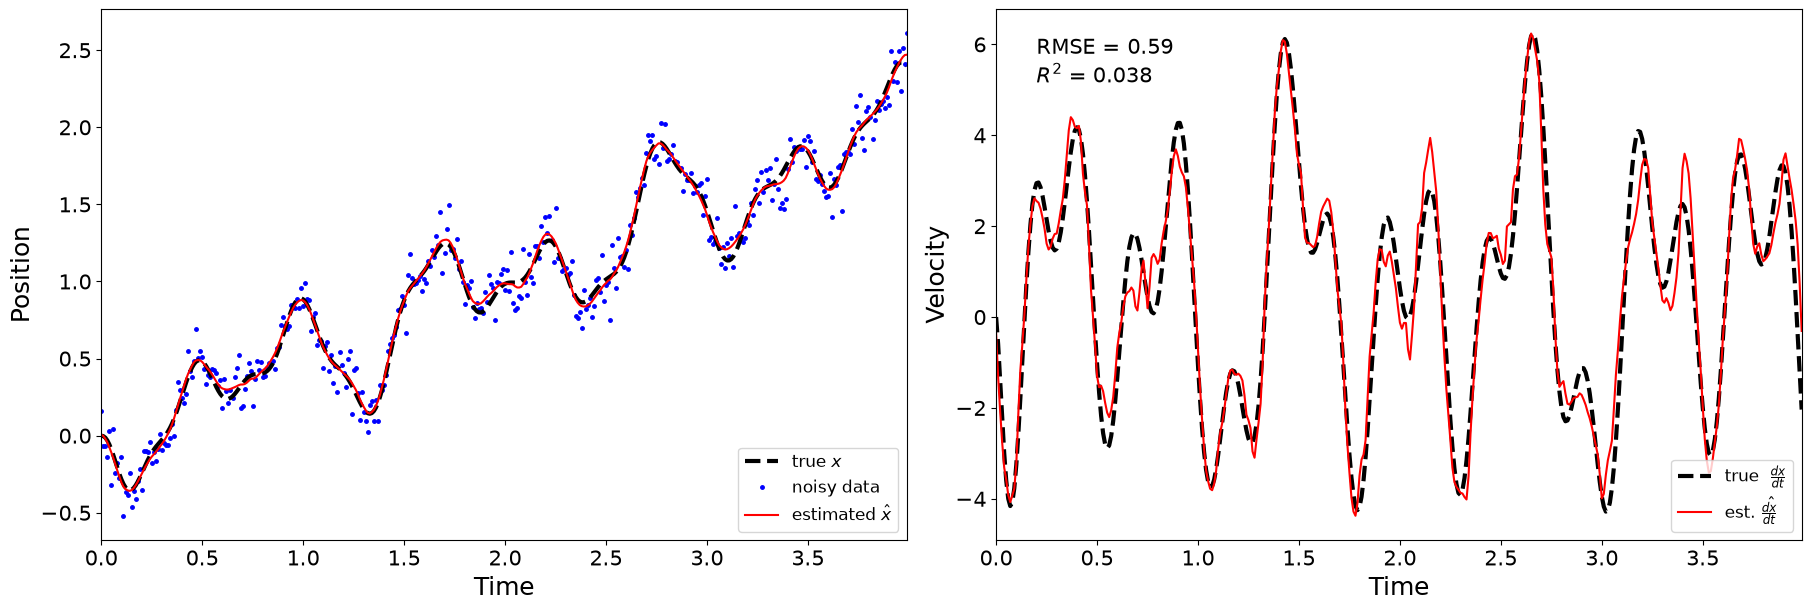

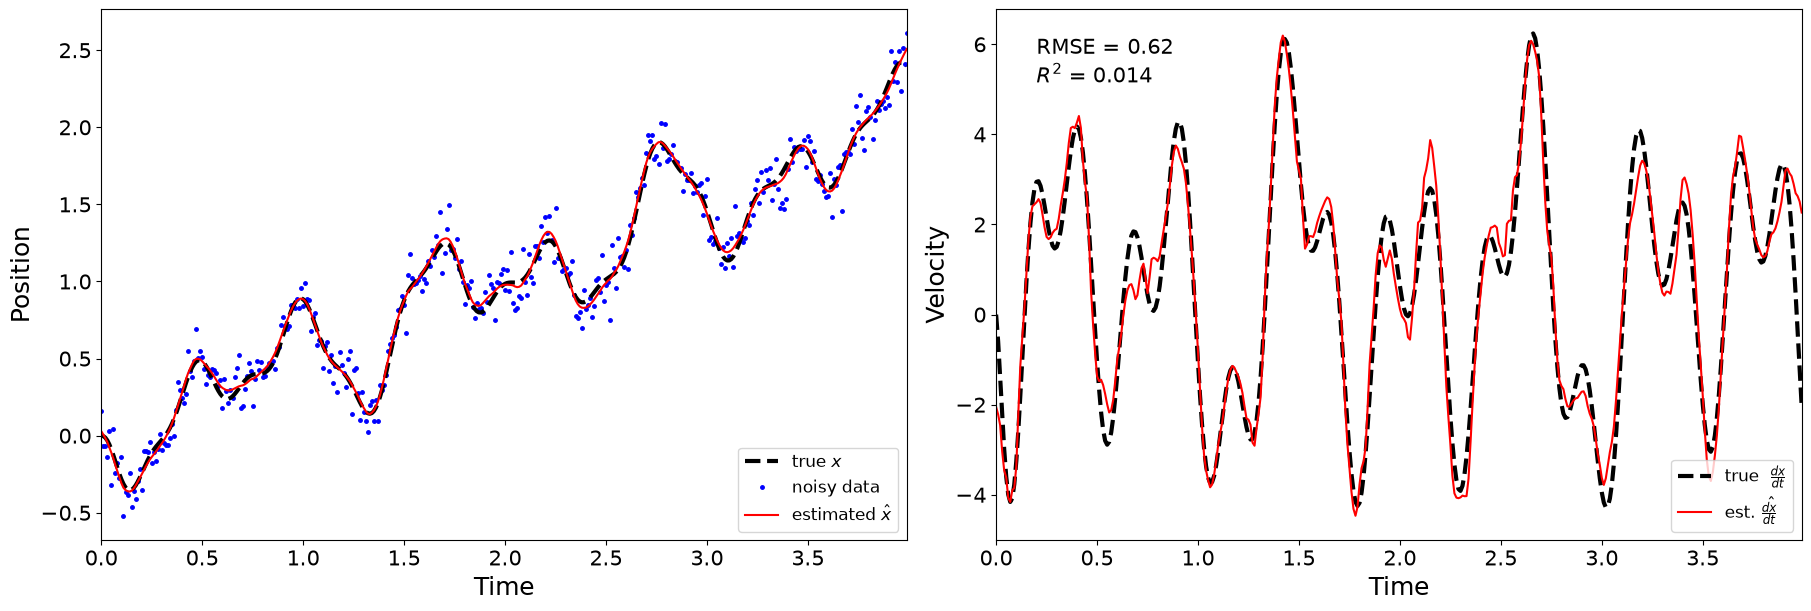

In [17]:
params, val = optimize(lineardiff, x, dt, dxdt_truth=dxdt_truth)
print('Optimal parameters:', params)
x_hat, dxdt_hat = lineardiff(x, dt, **params)
evaluate.plot(x, dt, x_hat, dxdt_hat, x_truth, dxdt_truth);

params, val = optimize(lineardiff, x, dt, bandlimit=bandlimit)
print('Optimal parameters:', params, 'cost:', val)
x_hat, dxdt_hat = lineardiff(x, dt, **params)
evaluate.plot(x, dt, x_hat, dxdt_hat, x_truth, dxdt_truth);